# Análise Exploratória de Dados de Telemetria Veicular

## Leandro Sabino da Silva

In [1]:
import os
import json

import numpy as np
import pandas as pd

import IPython
import matplotlib.pyplot as plt
import seaborn as sn
import sweetviz as sv

import warnings
warnings.filterwarnings("ignore")

In [2]:
path = os.getcwd()
path = path + "\\dados_telemetria_anonimizado"
arquivos = os.listdir(path)

In [3]:
arquivos

['sqs_lote_20260106T1500_anonimizado.jsonl',
 'sqs_lote_20260106T1530_anonimizado.jsonl',
 'sqs_lote_20260106T1600_anonimizado.jsonl',
 'sqs_lote_20260106T1630_anonimizado.jsonl',
 'sqs_lote_20260106T1700_anonimizado.jsonl',
 'sqs_lote_20260106T1730_anonimizado.jsonl',
 'sqs_lote_20260106T1800_anonimizado.jsonl',
 'sqs_lote_20260107T0800_anonimizado.jsonl',
 'sqs_lote_20260107T0830_anonimizado.jsonl',
 'sqs_lote_20260107T0900_anonimizado.jsonl',
 'sqs_lote_20260107T0930_anonimizado.jsonl',
 'sqs_lote_20260107T1000_anonimizado.jsonl',
 'sqs_lote_20260107T1030_anonimizado.jsonl',
 'sqs_lote_20260107T1100_anonimizado.jsonl',
 'sqs_lote_20260107T1130_anonimizado.jsonl',
 'sqs_lote_20260107T1200_anonimizado.jsonl',
 'sqs_lote_20260107T1230_anonimizado.jsonl',
 'sqs_lote_20260107T1300_anonimizado.jsonl',
 'sqs_lote_20260107T1330_anonimizado.jsonl',
 'sqs_lote_20260107T1400_anonimizado.jsonl',
 'sqs_lote_20260107T1430_anonimizado.jsonl',
 'sqs_lote_20260107T1500_anonimizado.jsonl',
 'sqs_lote

In [4]:
# Verificando uma amostra do conteúdo dos dados json

amostras = []

for arquivo in arquivos[:5]:
    caminho_arquivo = os.path.join(path, arquivo)

    with open(caminho_arquivo, "r", encoding="utf-8") as f:
        registro = json.loads(f.readline())

        # Abre todos os campos
        registro_aberto = pd.json_normalize(registro)

        # Só para adicionar o nome do arquivo
        registro_aberto["arquivo"] = arquivo

        amostras.append(registro_aberto)

df_amostra = pd.concat(amostras, ignore_index=True)

df_amostra

,sqs_message_id,received_at_utc,payload.id_equipamento,payload.customer,payload.veiculo,payload.placa,payload.vin,payload.data_posicao.$date,payload.data_chegada.$date,payload.velocidade,...,payload.coordenadas.type,payload.altitude,payload.heading,payload.hodometro,payload.gps_status,payload.ignicao,payload.eventCode,payload.bloqueio,payload.DriverId,arquivo
0,msg_00001,2025-07-10T18:13:18.423648Z,equip_00001,cliente_00001,veiculo_00001,placa__00001,vin__00001,2026-01-05T20:29:51.000Z,2026-01-05T20:30:00.931Z,65,...,Point,21.00,50,23534.723,True,True,44,False,None,sqs_lote_20260106T1500_anonimizado.jsonl
1,msg_02379,2025-07-10T18:41:46.970734Z,equip_00007,cliente_00001,veiculo_00007,placa__00007,vin__00007,2026-01-06T17:39:56.000Z,2026-01-06T18:41:45.661Z,0,...,Point,44.70,274,25445.288,True,False,11,False,motorista_00001,sqs_lote_20260106T1530_anonimizado.jsonl
2,msg_02429,2025-07-10T19:00:03.859232Z,equip_00008,cliente_00001,veiculo_00008,placa__00008,vin__00008,2026-01-06T18:59:53.000Z,2026-01-06T18:59:57.970Z,0,...,Point,56.00,0,19189.341,True,False,182,False,None,sqs_lote_20260106T1600_anonimizado.jsonl
3,msg_02546,2025-07-10T19:30:13.605522Z,equip_00004,cliente_00001,veiculo_00004,placa__00004,vin__00004,2026-01-06T19:30:08.000Z,2026-01-06T19:30:09.133Z,28,...,Point,44.68,281,27557.718,True,True,44,False,motorista_00001,sqs_lote_20260106T1630_anonimizado.jsonl
4,msg_02682,2025-07-10T20:00:05.560495Z,equip_00005,cliente_00001,veiculo_00005,placa__00005,vin__00005,2026-01-06T19:59:54.000Z,2026-01-06T19:59:59.618Z,92,...,Point,40.00,170,12308.264,True,True,44,False,None,sqs_lote_20260106T1700_anonimizado.jsonl


In [5]:
df_amostra.columns

Index(['sqs_message_id', 'received_at_utc', 'payload.id_equipamento',
       'payload.customer', 'payload.veiculo', 'payload.placa', 'payload.vin',
       'payload.data_posicao.$date', 'payload.data_chegada.$date',
       'payload.velocidade', 'payload.alim_ext', 'payload.bateria',
       'payload.coordenadas.coordinates', 'payload.coordenadas.type',
       'payload.altitude', 'payload.heading', 'payload.hodometro',
       'payload.gps_status', 'payload.ignicao', 'payload.eventCode',
       'payload.bloqueio', 'payload.DriverId', 'arquivo'],
      dtype='object')

### DATASET

- arquivos_sqs_consolidados.json - São informações das frotas de veículos obtidos dos equipamentos de telemetria. A partir do dicionário de dados, é possível descrever as seguintes variáveis:

1. *sqs_message_id* - O identificador único obtido do sistema de filas de mensagens da AWS.
2. *received_at_utc* - Dia e horário que o arquivo sqs foi gerado.
3. *id_equipamento* - Número serial do equipamento de telemetria.
4. *customer* - Identificador único do cliente que a empresa de telemetria está atendendo.
5. *veiculo* - Identificador único do veículo.
6. *placa* - Placa do veículo.
7. *vin* - Número de chassi.
8. *data_posicao* - Horário e data de quando a informação foi gerada pelo equipamento.
9. *data_chegada* - Horário e data de quandoa a informação foi recebida nos servidores da empresa de telemetria.
10. *velocidade* - Informação de velocidade em km/h.
11. *alim_ext* - Valor de tensão (em Volts) medida na alimentação do dispositivo de telemetria.
12. *bateria* - Valor de tensão (em Volts) medida na bateria interna do dispositivo de telemetria.
13. *coordenadas* - É um array de dois elementos com valores de longitude e latitude, respectivamente.
14. *type* - Indica que as coordenadas são pontos.
15. *altitude* - Valor de altitude medida pelo GPS (em metros).
16. *heading* - Valor de diração do GPS (em graus).
17. *hodometro* - Kilometragem percorrida pelo veículo (em km).
18. *gps_status* - Status do GPS (True/False).
19. *ignicao* - Estado de ignição do veículo (True/False).
20. *eventCode* - Código de evento registrado pelo dispositivo de telemetria.
21. *bloqueio* - Status de liberação do veículo (Bloqueado/True, Desbloqueado/False)
22. *DriverId* - Identificador do motorista.
23. *arquivo* - Nome do arquivo sqs lido.

In [6]:
caminho = os.getcwd() + "\\arquivos_sqs_consolidados.json"
caminho_json = pd.read_json(caminho)
dataset = pd.DataFrame(caminho_json)
dataset.head()

,sqs_message_id,received_at_utc,payload
0,msg_00001,2025-07-10T18:13:18.423648Z,"{'id_equipamento': 'equip_00001', 'customer': ..."
1,msg_00002,2025-07-10T18:13:18.435650Z,"{'id_equipamento': 'equip_00002', 'customer': ..."
2,msg_00003,2025-07-10T18:13:18.448651Z,"{'id_equipamento': 'equip_00002', 'customer': ..."
3,msg_00004,2025-07-10T18:13:18.460651Z,"{'id_equipamento': 'equip_00003', 'customer': ..."
4,msg_00005,2025-07-10T18:13:18.472652Z,"{'id_equipamento': 'equip_00002', 'customer': ..."


In [7]:
# Como payload é formado por dicionarios, é preciso reajustar
df_payload = pd.json_normalize(dataset["payload"])

frota_df = pd.concat( [dataset.drop(columns= "payload"), df_payload], 
                axis=1 )

frota_df.head()

,sqs_message_id,received_at_utc,id_equipamento,customer,veiculo,placa,vin,velocidade,alim_ext,bateria,...,hodometro,gps_status,ignicao,eventCode,bloqueio,DriverId,data_posicao.$date,data_chegada.$date,coordenadas.coordinates,coordenadas.type
0,msg_00001,2025-07-10T18:13:18.423648Z,equip_00001,cliente_00001,veiculo_00001,placa__00001,vin__00001,65,13.717,3.936,...,23534.723,True,True,44,False,None,2026-01-05T20:29:51.000Z,2026-01-05T20:30:00.931Z,"[-37.35874, -5.21315]",Point
1,msg_00002,2025-07-10T18:13:18.435650Z,equip_00002,cliente_00001,veiculo_00002,placa__00002,vin__00002,32,13.612,4.039,...,1834.835,True,True,44,False,None,2026-01-05T20:31:38.000Z,2026-01-05T20:31:43.188Z,"[-38.295986, -12.874523]",Point
2,msg_00003,2025-07-10T18:13:18.448651Z,equip_00002,cliente_00001,veiculo_00002,placa__00002,vin__00002,34,13.620,4.039,...,1835.431,True,True,252,False,None,2026-01-05T20:32:29.000Z,2026-01-05T20:32:42.545Z,"[-38.290726, -12.874628]",Point
3,msg_00004,2025-07-10T18:13:18.460651Z,equip_00003,cliente_00001,veiculo_00003,placa__00003,vin__00003,32,13.628,4.036,...,1269.223,True,True,44,False,None,2026-01-05T20:33:55.000Z,2026-01-05T20:34:01.265Z,"[-35.20908, -5.8236156]",Point
4,msg_00005,2025-07-10T18:13:18.472652Z,equip_00002,cliente_00001,veiculo_00002,placa__00002,vin__00002,17,13.676,4.039,...,1836.155,True,True,44,False,None,2026-01-05T20:34:07.000Z,2026-01-05T20:34:12.455Z,"[-38.28834, -12.879067]",Point


### Explorando o Dataset

In [8]:
print("Dimensão do Dataframe: ")
print("Frotas de veículos -", frota_df.shape)

Dimensão do Dataframe: 
Frotas de veículos - (308557, 22)


In [9]:
frota_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308557 entries, 0 to 308556
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   sqs_message_id           308557 non-null  object 
 1   received_at_utc          308557 non-null  object 
 2   id_equipamento           308557 non-null  object 
 3   customer                 308557 non-null  object 
 4   veiculo                  308557 non-null  object 
 5   placa                    308557 non-null  object 
 6   vin                      308557 non-null  object 
 7   velocidade               308557 non-null  int64  
 8   alim_ext                 308557 non-null  float64
 9   bateria                  308557 non-null  float64
 10  altitude                 308557 non-null  float64
 11  heading                  308557 non-null  int64  
 12  hodometro                308557 non-null  float64
 13  gps_status               308557 non-null  bool   
 14  igni

In [10]:
print("NaN ou Valores Ausentes:")
print(frota_df.isna().sum())

NaN ou Valores Ausentes:
sqs_message_id                 0
received_at_utc                0
id_equipamento                 0
customer                       0
veiculo                        0
placa                          0
vin                            0
velocidade                     0
alim_ext                       0
bateria                        0
altitude                       0
heading                        0
hodometro                      0
gps_status                     0
ignicao                        0
eventCode                      0
bloqueio                       0
DriverId                   94649
data_posicao.$date             0
data_chegada.$date             0
coordenadas.coordinates        0
coordenadas.type               0
dtype: int64


In [11]:
frota_df["DriverId"].unique()

array([None, 'motorista_00001', 'motorista_00002'], dtype=object)

In [12]:
len(frota_df["DriverId"])

308557

In [13]:
frota_df["DriverId"].isna().sum()

94649

In [14]:
Perc_Vazios_DriverId = frota_df["DriverId"].isna().sum() / len(frota_df["DriverId"])
print(Perc_Vazios_DriverId)


0.3067472136428602


In [15]:
#Dado que o percentual de valores vazios na variável DriverId é maior que 30% e a identificação de motoristas não contribui para a análise, 
# visto que temos a informação de placa de veículos, é possível remover essa variável

frota_df.drop(["DriverId"], axis = 1, inplace=True)

print(frota_df.columns)


Index(['sqs_message_id', 'received_at_utc', 'id_equipamento', 'customer',
       'veiculo', 'placa', 'vin', 'velocidade', 'alim_ext', 'bateria',
       'altitude', 'heading', 'hodometro', 'gps_status', 'ignicao',
       'eventCode', 'bloqueio', 'data_posicao.$date', 'data_chegada.$date',
       'coordenadas.coordinates', 'coordenadas.type'],
      dtype='object')


In [16]:
print("customer: ", frota_df["customer"].unique(), "\n")
print("vin: ", frota_df["vin"].unique(), "\n")
print("placa: ", frota_df["placa"].unique(), "\n")
print("received_at_utc: ", frota_df["received_at_utc"].unique(), "\n")
print("veiculo: ", frota_df["veiculo"].unique())

customer:  ['cliente_00001'] 

vin:  ['vin__00001' 'vin__00002' 'vin__00003' 'vin__00004' 'vin__00005'
 'vin__00006' 'vin__00007' 'vin__00008' 'vin__00009' 'vin__00010'
 'vin__00011' 'vin__00012' 'vin__00013' 'vin__00014' 'vin__00015'
 'vin__00016' 'vin__00017' 'vin__00018' 'vin__00019' 'vin__00020'
 'vin__00021' 'vin__00022'] 

placa:  ['placa__00001' 'placa__00002' 'placa__00003' 'placa__00004'
 'placa__00005' 'placa__00006' 'placa__00007' 'placa__00008'
 'placa__00009' 'placa__00010' 'placa__00011' 'placa__00012'
 'placa__00013' 'placa__00014' 'placa__00015' 'placa__00016'
 'placa__00017' 'placa__00018' 'placa__00019' 'placa__00020'
 'placa__00021' 'placa__00022'] 

received_at_utc:  ['2025-07-10T18:13:18.423648Z' '2025-07-10T18:13:18.435650Z'
 '2025-07-10T18:13:18.448651Z' ... '2025-10-25T15:59:46.443385Z'
 '2025-10-25T15:59:51.400768Z' '2025-10-25T15:59:55.568077Z'] 

veiculo:  ['veiculo_00001' 'veiculo_00002' 'veiculo_00003' 'veiculo_00004'
 'veiculo_00005' 'veiculo_00006' 'veicu

In [17]:
#Visto que variáveis como customer, vin, received_at_utc e placa não constribuem diretamente para a análise por terem valores excessivamente 
# repetidos ou de apenas identificação de veiculos, é possível descartar do dataframe
frota_df.drop(columns=["customer", "vin", "placa", "received_at_utc"], inplace=True)


In [18]:
# As datas de posição e chegada representam apenas o tempo entre a informação gerada nos dispositivos e sua chegada nos servidores. 
# Por efeitos de análise, apenas será utilizada o tempo de geração de informação no dispositivo

frota_df.drop(columns=["data_chegada.$date"], inplace= True)

In [19]:
# As variáveis "alim_ext" e "bateria" são, respectivamente, a tensão de alimentação externa do dispositivo de telemetria e a tensão de bateria interna do dispositivo.
# Ambas as variáveis não farão parte da nossa análise e por isso serão descartadas

frota_df.drop(columns=["alim_ext", "bateria"], inplace=True)

In [20]:
# A variável de identificação do equipamento de telemetria (id_equipamento) também não fará parte da análise
frota_df.drop(columns=["id_equipamento"], inplace = True)

In [21]:
# A variável heading indica, em graus, para qual direção (Norte, Sul, Leste, etc) o veículo estava se movendo enquanto estava se movendo
# Visto que temos dados de latitude e longitude que contribuem com a geolocalização, a variável heading pouco contribui para nossa análise
# de eventos de comportamento de motorista e por isso será desconsiderada
frota_df.drop(columns=["heading"], inplace=True)

In [22]:
frota_df

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,data_posicao.$date,coordenadas.coordinates,coordenadas.type
0,msg_00001,veiculo_00001,65,21.00,23534.723,True,True,44,False,2026-01-05T20:29:51.000Z,"[-37.35874, -5.21315]",Point
1,msg_00002,veiculo_00002,32,18.00,1834.835,True,True,44,False,2026-01-05T20:31:38.000Z,"[-38.295986, -12.874523]",Point
2,msg_00003,veiculo_00002,34,12.00,1835.431,True,True,252,False,2026-01-05T20:32:29.000Z,"[-38.290726, -12.874628]",Point
3,msg_00004,veiculo_00003,32,47.00,1269.223,True,True,44,False,2026-01-05T20:33:55.000Z,"[-35.20908, -5.8236156]",Point
4,msg_00005,veiculo_00002,17,12.00,1836.155,True,True,44,False,2026-01-05T20:34:07.000Z,"[-38.28834, -12.879067]",Point
...,...,...,...,...,...,...,...,...,...,...,...,...
308552,msg_308553,veiculo_00017,19,37.44,22729.718,True,True,44,False,2026-04-23T15:59:21.000Z,"[-38.4961606, -12.5130561]",Point
308553,msg_308554,veiculo_00015,29,86.00,38755.182,True,True,44,False,2026-04-23T15:59:09.000Z,"[-38.56614, -12.666601]",Point
308554,msg_308555,veiculo_00017,18,40.38,22729.800,True,True,44,False,2026-04-23T15:59:44.000Z,"[-38.4953771, -12.5131385]",Point
308555,msg_308556,veiculo_00017,19,38.91,22729.834,True,True,44,False,2026-04-23T15:59:50.000Z,"[-38.495308, -12.5128825]",Point


In [23]:
# Variaveis [longitude, latitude] com base em [coodernadas.coordinate]
f_1 = lambda x: x[1]
frota_df["latitude"] = frota_df["coordenadas.coordinates"].apply(f_1)

f_2 = lambda x: x[0]
frota_df["longitude"] = frota_df["coordenadas.coordinates"].apply(f_2)

frota_df.drop(columns=["coordenadas.coordinates", "coordenadas.type"], inplace=True)


In [24]:
frota_df

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,data_posicao.$date,latitude,longitude
0,msg_00001,veiculo_00001,65,21.00,23534.723,True,True,44,False,2026-01-05T20:29:51.000Z,-5.213150,-37.358740
1,msg_00002,veiculo_00002,32,18.00,1834.835,True,True,44,False,2026-01-05T20:31:38.000Z,-12.874523,-38.295986
2,msg_00003,veiculo_00002,34,12.00,1835.431,True,True,252,False,2026-01-05T20:32:29.000Z,-12.874628,-38.290726
3,msg_00004,veiculo_00003,32,47.00,1269.223,True,True,44,False,2026-01-05T20:33:55.000Z,-5.823616,-35.209080
4,msg_00005,veiculo_00002,17,12.00,1836.155,True,True,44,False,2026-01-05T20:34:07.000Z,-12.879067,-38.288340
...,...,...,...,...,...,...,...,...,...,...,...,...
308552,msg_308553,veiculo_00017,19,37.44,22729.718,True,True,44,False,2026-04-23T15:59:21.000Z,-12.513056,-38.496161
308553,msg_308554,veiculo_00015,29,86.00,38755.182,True,True,44,False,2026-04-23T15:59:09.000Z,-12.666601,-38.566140
308554,msg_308555,veiculo_00017,18,40.38,22729.800,True,True,44,False,2026-04-23T15:59:44.000Z,-12.513139,-38.495377
308555,msg_308556,veiculo_00017,19,38.91,22729.834,True,True,44,False,2026-04-23T15:59:50.000Z,-12.512882,-38.495308


In [25]:
# Dicionário de mapeamento dos códigos de evento
mapa_event_code = {
    1: "Início do trajeto",
    2: "Fim de trajeto",
    11: "Report ignição off",
    44: "Report ignição on",
    53: "Ignição desligada",
    69: "Ignição ligada",
    90: "Velocidade acima do limite",
    91: "Velocidade abaixo do limite",
    110: "Aceleração Leve",
    111: "Freada Leve",
    112: "Curva Leve esquerda",
    113: "Curva Leve direita",
    120: "Aceleração Brusca",
    121: "Freada Brusca",
    122: "Curva Brusca esquerda",
    123: "Curva Brusca direita"
}

# Criação da nova coluna com a descrição do evento
frota_df["descricao_evento"] = frota_df["eventCode"].map(mapa_event_code).fillna("Outros eventos")

In [26]:
frota_df

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,data_posicao.$date,latitude,longitude,descricao_evento
0,msg_00001,veiculo_00001,65,21.00,23534.723,True,True,44,False,2026-01-05T20:29:51.000Z,-5.213150,-37.358740,Report ignição on
1,msg_00002,veiculo_00002,32,18.00,1834.835,True,True,44,False,2026-01-05T20:31:38.000Z,-12.874523,-38.295986,Report ignição on
2,msg_00003,veiculo_00002,34,12.00,1835.431,True,True,252,False,2026-01-05T20:32:29.000Z,-12.874628,-38.290726,Outros eventos
3,msg_00004,veiculo_00003,32,47.00,1269.223,True,True,44,False,2026-01-05T20:33:55.000Z,-5.823616,-35.209080,Report ignição on
4,msg_00005,veiculo_00002,17,12.00,1836.155,True,True,44,False,2026-01-05T20:34:07.000Z,-12.879067,-38.288340,Report ignição on
...,...,...,...,...,...,...,...,...,...,...,...,...,...
308552,msg_308553,veiculo_00017,19,37.44,22729.718,True,True,44,False,2026-04-23T15:59:21.000Z,-12.513056,-38.496161,Report ignição on
308553,msg_308554,veiculo_00015,29,86.00,38755.182,True,True,44,False,2026-04-23T15:59:09.000Z,-12.666601,-38.566140,Report ignição on
308554,msg_308555,veiculo_00017,18,40.38,22729.800,True,True,44,False,2026-04-23T15:59:44.000Z,-12.513139,-38.495377,Report ignição on
308555,msg_308556,veiculo_00017,19,38.91,22729.834,True,True,44,False,2026-04-23T15:59:50.000Z,-12.512882,-38.495308,Report ignição on


In [27]:
frota_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308557 entries, 0 to 308556
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   sqs_message_id      308557 non-null  object 
 1   veiculo             308557 non-null  object 
 2   velocidade          308557 non-null  int64  
 3   altitude            308557 non-null  float64
 4   hodometro           308557 non-null  float64
 5   gps_status          308557 non-null  bool   
 6   ignicao             308557 non-null  bool   
 7   eventCode           308557 non-null  int64  
 8   bloqueio            308557 non-null  bool   
 9   data_posicao.$date  308557 non-null  object 
 10  latitude            308557 non-null  float64
 11  longitude           308557 non-null  float64
 12  descricao_evento    308557 non-null  object 
dtypes: bool(3), float64(4), int64(2), object(4)
memory usage: 24.4+ MB


In [28]:
frota_df["velocidade"].describe()

count    308557.000000
mean         23.642030
std          26.173679
min           0.000000
25%           0.000000
50%          16.000000
75%          37.000000
max         158.000000
Name: velocidade, dtype: float64

In [29]:
# Criando a variável de faixas de velocidade
bins_velocidade = [
    -0.01,   # limite inferior
    0,       #veículo parado
    20,      # até 20 km/h
    40,      # até 40 km/h
    60,      #até 60 km/h
    80,      #até 80 km/h
    100,     # até 100 km/h
    120,     #até 120 km/h
    np.inf   # qualquer valor acima de 120
]

labels_velocidade = [
    "0 km/h - Veículo parado",
    "1 a 20 km/h - Velocidade muito baixa",
    "21 a 40 km/h - Velocidade baixa",
    "41 a 60 km/h - Velocidade urbana",
    "61 a 80 km/h - Velocidade moderada",
    "81 a 100 km/h - Velocidade alta",
    "101 a 120 km/h - Velocidade muito alta",
    "Acima de 120 km/h - Velocidade crítica"
]

frota_df["faixas_velocidade"] = pd.cut(
                                        frota_df["velocidade"],
                                        bins=bins_velocidade,
                                        labels=labels_velocidade,
                                        include_lowest=True
)


In [30]:
# Os codigos de evento descritos na variavel "descricao_evento" nem sempre representam faltas graves para a nossa análise, por isso classifiquei em
# eventos graves, leves ou operacionais

mapa_gravidade_evento = {
    90: "Crítico / irregularidade",
    120: "Crítico / irregularidade",
    121: "Crítico / irregularidade",
    122: "Crítico / irregularidade",
    123: "Crítico / irregularidade",

    110: "Leve / atenção",
    111: "Leve / atenção",
    112: "Leve / atenção",
    113: "Leve / atenção",

    1: "Operacional / status",
    2: "Operacional / status",
    11: "Operacional / status",
    44: "Operacional / status",
    53: "Operacional / status",
    69: "Operacional / status",
    91: "Operacional / status"
}

frota_df["gravidade_evento"] = frota_df["eventCode"].map(mapa_gravidade_evento).fillna("Outros eventos")

In [31]:
# Extraindo valores de data e hora da coluna data_posicao.$date

frota_df["data_posicao.$date"] = pd.to_datetime(frota_df["data_posicao.$date"], errors= "coerce")

frota_df["data_posicao"] = frota_df["data_posicao.$date"].dt.strftime("%d/%m/%Y")
frota_df["hora_posicao"] = frota_df["data_posicao.$date"].dt.strftime("%H:%M:%S")



In [32]:
# Divisão de turnos de acordo com os horários:
# Matutino 06h às 14h, Vespertino 14 às 22h e Noturno 22h às 06h
def turno(hora):
    if hora >= "06:00:00" and hora < "14:00:00":
        return "Matutino"

    elif hora >= "14:00:00" and hora < "22:00:00":
        return "Vespertino"
    
    else:
        return "Noturno"
    
frota_df["turno"] = frota_df["hora_posicao"].apply(turno)



In [33]:
# Extraindo os dias da semana
semana = ["segunda", "terca", "quarta", "quinta", "sexta", "sabado", "domingo"]

f_dia = lambda x: semana[x.weekday()]
frota_df["dia"] = frota_df["data_posicao.$date"].apply(f_dia)

frota_df.drop(columns= ["data_posicao.$date"], inplace = True)

In [34]:
frota_df

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,latitude,longitude,descricao_evento,faixas_velocidade,gravidade_evento,data_posicao,hora_posicao,turno,dia
0,msg_00001,veiculo_00001,65,21.00,23534.723,True,True,44,False,-5.213150,-37.358740,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,05/01/2026,20:29:51,Vespertino,segunda
1,msg_00002,veiculo_00002,32,18.00,1834.835,True,True,44,False,-12.874523,-38.295986,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:31:38,Vespertino,segunda
2,msg_00003,veiculo_00002,34,12.00,1835.431,True,True,252,False,-12.874628,-38.290726,Outros eventos,21 a 40 km/h - Velocidade baixa,Outros eventos,05/01/2026,20:32:29,Vespertino,segunda
3,msg_00004,veiculo_00003,32,47.00,1269.223,True,True,44,False,-5.823616,-35.209080,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:55,Vespertino,segunda
4,msg_00005,veiculo_00002,17,12.00,1836.155,True,True,44,False,-12.879067,-38.288340,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,05/01/2026,20:34:07,Vespertino,segunda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308552,msg_308553,veiculo_00017,19,37.44,22729.718,True,True,44,False,-12.513056,-38.496161,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,23/04/2026,15:59:21,Vespertino,quinta
308553,msg_308554,veiculo_00015,29,86.00,38755.182,True,True,44,False,-12.666601,-38.566140,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,23/04/2026,15:59:09,Vespertino,quinta
308554,msg_308555,veiculo_00017,18,40.38,22729.800,True,True,44,False,-12.513139,-38.495377,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,23/04/2026,15:59:44,Vespertino,quinta
308555,msg_308556,veiculo_00017,19,38.91,22729.834,True,True,44,False,-12.512882,-38.495308,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,23/04/2026,15:59:50,Vespertino,quinta


In [35]:
# Visualizações criadas pelo sweetviz

frota_df_report = sv.analyze(frota_df[["velocidade","faixas_velocidade", "altitude", "hodometro", "gps_status", "ignicao", "bloqueio", "gravidade_evento"]])

frota_df_report.show_html("frota_df.html", open_browser = False)

IPython.display.IFrame("frota_df.html", width = 1280, height = 720)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report frota_df.html was generated.


# Perguntas

### 1. Panorama da frota

1. Quantos veículos distintos existem na base?
2. Qual é o período coberto pelos dados de telemetria?
3. Quais veículos concentram mais registros e maior quilometragem?
4. Em quais dias da semana e turnos há maior atividade da frota?


### 2. Qualidade do dispositivo de GPS
1. Qual percentual de registros possui GPS desligado?
2. Quais veículos têm maior proporção de GPS desligado?
3. Existem registros de veículos em movimento com GPS desligado?
4. Existem registros com hodômetro zerado, nulo ou diminuindo ao longo do tempo?


### 3. Uso e estado operacional da ignição
1. Quais veículos passam mais tempo parados com ignição ligada?
2. Existem registros com ignição desligada e velocidade maior que zero?


### 4. Velocidade e comportamento de condução
1. Qual é a distribuição geral das faixas de velocidade?
2. Quais veículos apresentam maior recorrência em faixas elevadas de velocidade?
3. A velocidade registrada está coerente com os eventos de velocidade acima do limite?
4. Em quais turnos ocorrem mais eventos de excesso de velocidade?


### 5. Eventos críticos e irregularidades
1. Como os eventos se distribuem entre crítico, leve e operacional?
2. Quais tipos de eventos críticos são mais frequentes?
3. Quais veículos concentram mais eventos críticos?
4. Eventos críticos se concentram em turnos específicos?
5. Existem veículos com excesso de eventos leves que indiquem padrão de atenção?


### 6. Bloqueio e inconsistências operacionais
1. Quais veículos tiveram estado de bloqueio?
2. Existem veículos bloqueados com velocidade maior que zero?
3. Existem veículos bloqueados com ignição ligada?
4. Existem registros com evento crítico de velocidade acima do limite, mas velocidade registrada baixa?


### 7. Priorização de veículos
1. Quais veículos deveriam ser priorizados para investigação operacional?
2. Quais veículos apresentam melhor comportamento operacional?


In [36]:
frota_df

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,latitude,longitude,descricao_evento,faixas_velocidade,gravidade_evento,data_posicao,hora_posicao,turno,dia
0,msg_00001,veiculo_00001,65,21.00,23534.723,True,True,44,False,-5.213150,-37.358740,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,05/01/2026,20:29:51,Vespertino,segunda
1,msg_00002,veiculo_00002,32,18.00,1834.835,True,True,44,False,-12.874523,-38.295986,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:31:38,Vespertino,segunda
2,msg_00003,veiculo_00002,34,12.00,1835.431,True,True,252,False,-12.874628,-38.290726,Outros eventos,21 a 40 km/h - Velocidade baixa,Outros eventos,05/01/2026,20:32:29,Vespertino,segunda
3,msg_00004,veiculo_00003,32,47.00,1269.223,True,True,44,False,-5.823616,-35.209080,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:55,Vespertino,segunda
4,msg_00005,veiculo_00002,17,12.00,1836.155,True,True,44,False,-12.879067,-38.288340,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,05/01/2026,20:34:07,Vespertino,segunda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308552,msg_308553,veiculo_00017,19,37.44,22729.718,True,True,44,False,-12.513056,-38.496161,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,23/04/2026,15:59:21,Vespertino,quinta
308553,msg_308554,veiculo_00015,29,86.00,38755.182,True,True,44,False,-12.666601,-38.566140,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,23/04/2026,15:59:09,Vespertino,quinta
308554,msg_308555,veiculo_00017,18,40.38,22729.800,True,True,44,False,-12.513139,-38.495377,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,23/04/2026,15:59:44,Vespertino,quinta
308555,msg_308556,veiculo_00017,19,38.91,22729.834,True,True,44,False,-12.512882,-38.495308,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,23/04/2026,15:59:50,Vespertino,quinta


In [37]:
# 1. Panorama da Frota
print( frota_df["veiculo"].unique())
print("Qtd de veículos distintos: ", frota_df["veiculo"].nunique() )

['veiculo_00001' 'veiculo_00002' 'veiculo_00003' 'veiculo_00004'
 'veiculo_00005' 'veiculo_00006' 'veiculo_00007' 'veiculo_00008'
 'veiculo_00009' 'veiculo_00010' 'veiculo_00011' 'veiculo_00012'
 'veiculo_00013' 'veiculo_00014' 'veiculo_00015' 'veiculo_00016'
 'veiculo_00017' 'veiculo_00018' 'veiculo_00019' 'veiculo_00020'
 'veiculo_00021' 'veiculo_00022' 'veiculo_00023']
Qtd de veículos distintos:  23


In [38]:
data_posicao_datetime = pd.to_datetime(
    frota_df["data_posicao"],
    format="%d/%m/%Y",
    errors="coerce")


print("Início da coleta de dados: ", data_posicao_datetime.min().strftime("%d/%m/%Y") )
print("Fim da coleta de dados: ",data_posicao_datetime.max().strftime("%d/%m/%Y") )

Início da coleta de dados:  05/01/2026
Fim da coleta de dados:  23/04/2026


In [39]:
resumo_veiculos = (
    frota_df
    .groupby("veiculo")
    .agg(
        qtd_registros=("veiculo", "count"),
        hodometro_min=("hodometro", "min"),
        hodometro_max=("hodometro", "max")
    )
    .reset_index()
)

resumo_veiculos["km_registrado"] = (
    resumo_veiculos["hodometro_max"] - resumo_veiculos["hodometro_min"]
)

print("Resumo dos veiculos: ")
print(resumo_veiculos)

Resumo dos veiculos: 
          veiculo  qtd_registros  hodometro_min  hodometro_max  km_registrado
0   veiculo_00001           8279      23534.723      25845.639       2310.916
1   veiculo_00002          27936       1834.585      11324.535       9489.950
2   veiculo_00003            174       1267.285       1311.947         44.662
3   veiculo_00004          31479      27485.482      33882.481       6396.999
4   veiculo_00005          21557      12169.023      20049.288       7880.265
5   veiculo_00006          20254       2583.099       7514.472       4931.373
6   veiculo_00007          20891      25312.681      34575.207       9262.526
7   veiculo_00008          28592      19038.229      29040.149      10001.920
8   veiculo_00009           2121       6584.821       6903.275        318.454
9   veiculo_00010          25528      32790.445      41132.756       8342.311
10  veiculo_00011           5552       3498.743       5369.316       1870.573
11  veiculo_00012          16910      2235

In [40]:
top_registros = resumo_veiculos.sort_values(by = "qtd_registros", ascending = False)
top_registros

,veiculo,qtd_registros,hodometro_min,hodometro_max,km_registrado
3,veiculo_00004,31479,27485.482,33882.481,6396.999
12,veiculo_00013,30642,35033.436,41474.234,6440.798
7,veiculo_00008,28592,19038.229,29040.149,10001.920
1,veiculo_00002,27936,1834.585,11324.535,9489.950
14,veiculo_00015,26917,29464.813,38755.182,9290.369
9,veiculo_00010,25528,32790.445,41132.756,8342.311
4,veiculo_00005,21557,12169.023,20049.288,7880.265
6,veiculo_00007,20891,25312.681,34575.207,9262.526
5,veiculo_00006,20254,2583.099,7514.472,4931.373
11,veiculo_00012,16910,22358.768,25270.920,2912.152


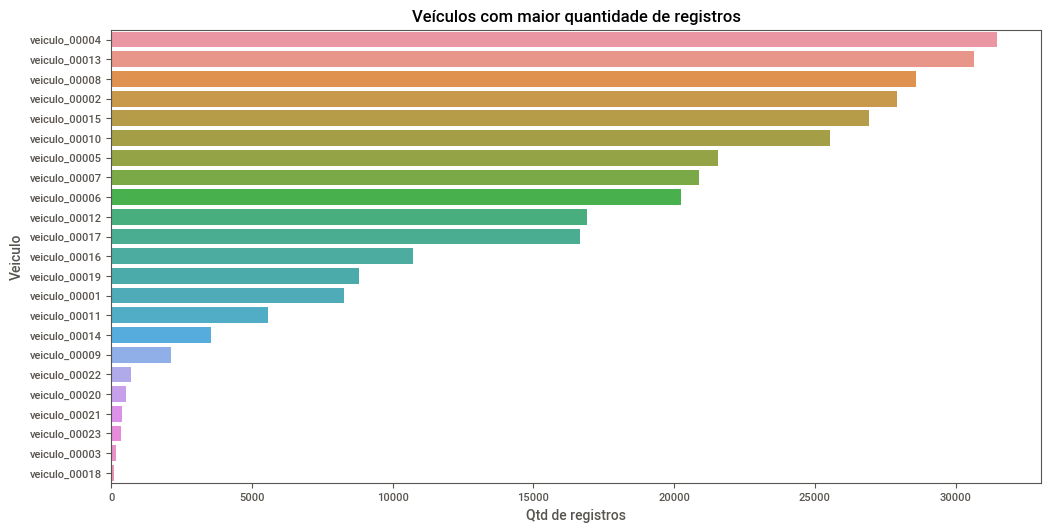

In [41]:
plt.figure(figsize= (12, 6))

sn.barplot(
            data = top_registros,
            x = "qtd_registros",
            y = "veiculo"
)

plt.title("Veículos com maior quantidade de registros")
plt.xlabel("Qtd de registros")
plt.ylabel("Veiculo")

plt.show()

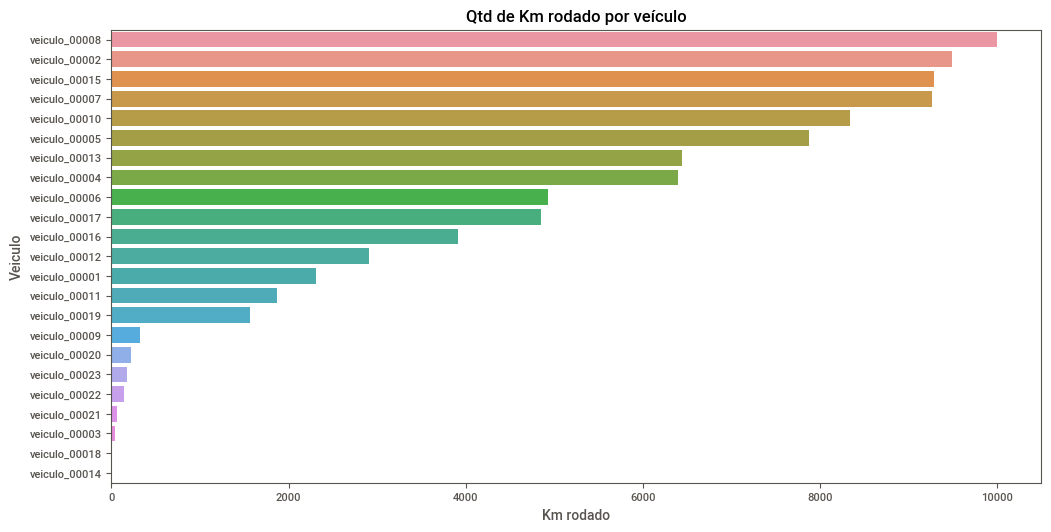

In [42]:
top_km = resumo_veiculos.sort_values(by = "km_registrado", ascending= False)

plt.figure(figsize = (12,6))

sn.barplot(
    data = top_km,
    x = "km_registrado",
    y = "veiculo"
)

plt.title("Qtd de Km rodado por veículo")
plt.xlabel("Km rodado")
plt.ylabel("Veiculo")

plt.show()

In [43]:
atividade_turno_dia = (
    frota_df
    .groupby(["dia", "turno"])
    .size()
    .reset_index(name="qtd_registros")
)
atividade_turno_dia


,dia,turno,qtd_registros
0,domingo,Matutino,4408
1,domingo,Noturno,3173
2,domingo,Vespertino,6087
3,quarta,Matutino,24295
4,quarta,Noturno,4496
5,quarta,Vespertino,28524
6,quinta,Matutino,23164
7,quinta,Noturno,4828
8,quinta,Vespertino,28294
9,sabado,Matutino,7448


In [44]:
# Ordenação para que os dias da semana comecem no domingo e terminem no sábado

ordem_dias = [
    "domingo",
    "segunda",
    "terca",
    "quarta",
    "quinta",
    "sexta",
    "sabado"
]

atividade_turno_dia["dia"] = pd.Categorical(
    atividade_turno_dia["dia"],
    categories=ordem_dias,
    ordered=True
)


# Ordenação para os turnos: Matutino, Vespertino e Noturno nessa ordem

ordem_turnos = ["Matutino", "Vespertino", "Noturno"]
atividade_turno_dia["turno"] = pd.Categorical(atividade_turno_dia["turno"], categories = ordem_turnos, ordered = True)

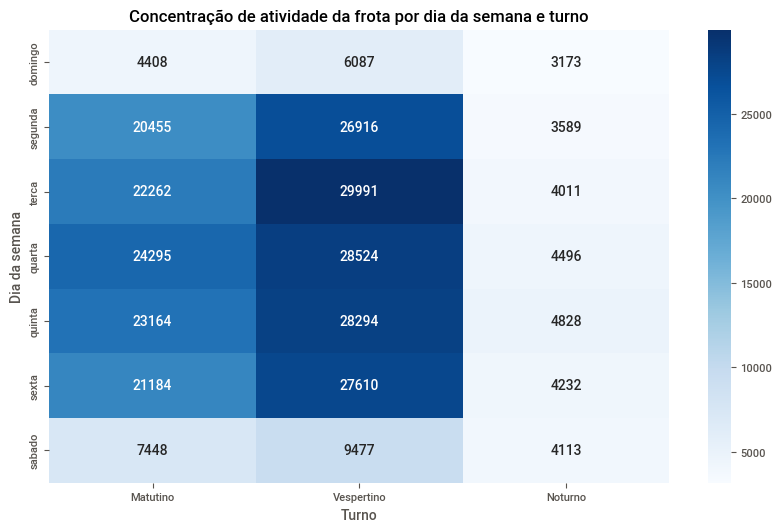

In [45]:
tabela_heatmap = atividade_turno_dia.pivot_table(
    index="dia",
    columns="turno",
    values="qtd_registros",
    aggfunc="sum"
)

plt.figure(figsize=(10, 6))

sn.heatmap(
    tabela_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Concentração de atividade da frota por dia da semana e turno")
plt.xlabel("Turno")
plt.ylabel("Dia da semana")

plt.show()

### 1. Panorama da Frota

- Existem 23 veículos na base
- Os dados de telemetria compreendem o período entre 05/01/26 a 23/04/26
- O top3 veículos que concentram mais registros nesse período são, respectivamente: veiculo_00004, veiculo_00013 e veiculo_00008
- O top3 veiculos que concentram mais km rodados nesse período, respectivamente: veiculo_00008, veiculo_00002 e veiculo_00015
- O comportamento de operação da frota se concentra nos dias úteis (segunda a sexta) em turno comercial (Matutino e Vespertino)

In [46]:
frota_df

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,latitude,longitude,descricao_evento,faixas_velocidade,gravidade_evento,data_posicao,hora_posicao,turno,dia
0,msg_00001,veiculo_00001,65,21.00,23534.723,True,True,44,False,-5.213150,-37.358740,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,05/01/2026,20:29:51,Vespertino,segunda
1,msg_00002,veiculo_00002,32,18.00,1834.835,True,True,44,False,-12.874523,-38.295986,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:31:38,Vespertino,segunda
2,msg_00003,veiculo_00002,34,12.00,1835.431,True,True,252,False,-12.874628,-38.290726,Outros eventos,21 a 40 km/h - Velocidade baixa,Outros eventos,05/01/2026,20:32:29,Vespertino,segunda
3,msg_00004,veiculo_00003,32,47.00,1269.223,True,True,44,False,-5.823616,-35.209080,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:55,Vespertino,segunda
4,msg_00005,veiculo_00002,17,12.00,1836.155,True,True,44,False,-12.879067,-38.288340,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,05/01/2026,20:34:07,Vespertino,segunda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308552,msg_308553,veiculo_00017,19,37.44,22729.718,True,True,44,False,-12.513056,-38.496161,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,23/04/2026,15:59:21,Vespertino,quinta
308553,msg_308554,veiculo_00015,29,86.00,38755.182,True,True,44,False,-12.666601,-38.566140,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,23/04/2026,15:59:09,Vespertino,quinta
308554,msg_308555,veiculo_00017,18,40.38,22729.800,True,True,44,False,-12.513139,-38.495377,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,23/04/2026,15:59:44,Vespertino,quinta
308555,msg_308556,veiculo_00017,19,38.91,22729.834,True,True,44,False,-12.512882,-38.495308,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,23/04/2026,15:59:50,Vespertino,quinta


In [102]:
gps_desligado = (frota_df["gps_status"] == False).mean() * 100
print("Percentual de registros com o gps desligado: ",round(gps_desligado,2), "%")

Percentual de registros com o gps desligado:  1.75 %


In [48]:
resumo_gps_off = (
    frota_df[frota_df["gps_status"] == False]
    .groupby("veiculo")
    .size()
    .reset_index(name="qtd_gps_off")
    .sort_values(by = "qtd_gps_off",ascending=False)
    
)

resumo_gps_off

,veiculo,qtd_gps_off
3,veiculo_00004,638
12,veiculo_00013,562
5,veiculo_00006,493
14,veiculo_00015,477
7,veiculo_00008,466
9,veiculo_00010,431
11,veiculo_00012,418
6,veiculo_00007,324
0,veiculo_00001,304
16,veiculo_00017,289


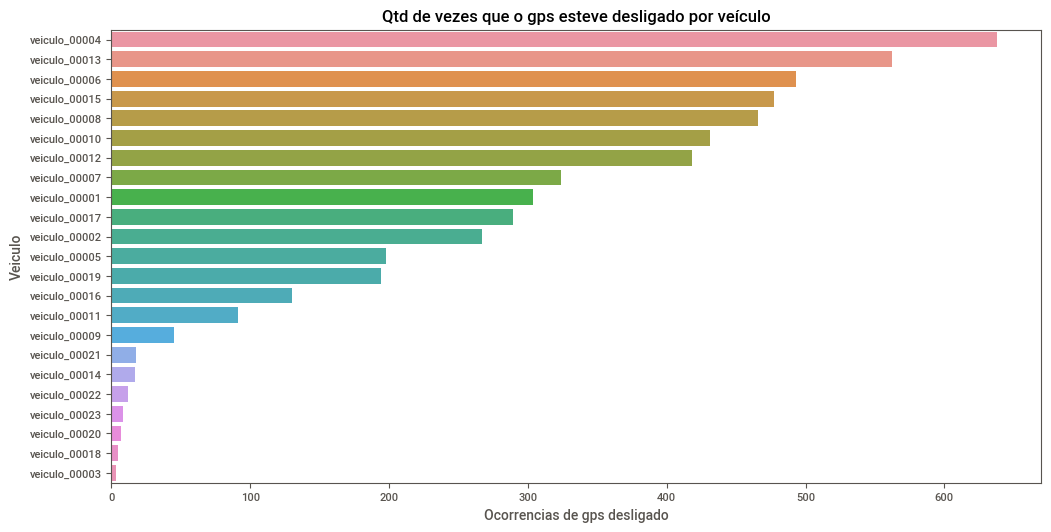

In [49]:
top_gps_off = resumo_gps_off.sort_values(by = "qtd_gps_off", ascending= False)

plt.figure(figsize = (12,6))

sn.barplot(
    data = top_gps_off,
    x = "qtd_gps_off",
    y = "veiculo"
)

plt.title("Qtd de vezes que o gps esteve desligado por veículo")
plt.xlabel("Ocorrencias de gps desligado")
plt.ylabel("Veiculo")

plt.show()

In [50]:
# para o veiculo em movimento, vamos considerar que sua velocidade > 0
resumo_veiculo_gps_off = (
    frota_df[ (frota_df["velocidade"] > 0) & (frota_df["gps_status"] == False) ]
    .groupby("veiculo")
    .size()
    .reset_index(name = "ocorr_vel_acima_0_gps_off")
    .sort_values(by = "ocorr_vel_acima_0_gps_off", ascending= False)
)

resumo_veiculo_gps_off

,veiculo,ocorr_vel_acima_0_gps_off
4,veiculo_00006,11
5,veiculo_00007,8
0,veiculo_00001,7
7,veiculo_00012,6
6,veiculo_00010,4
2,veiculo_00004,3
1,veiculo_00002,2
3,veiculo_00005,1
8,veiculo_00013,1


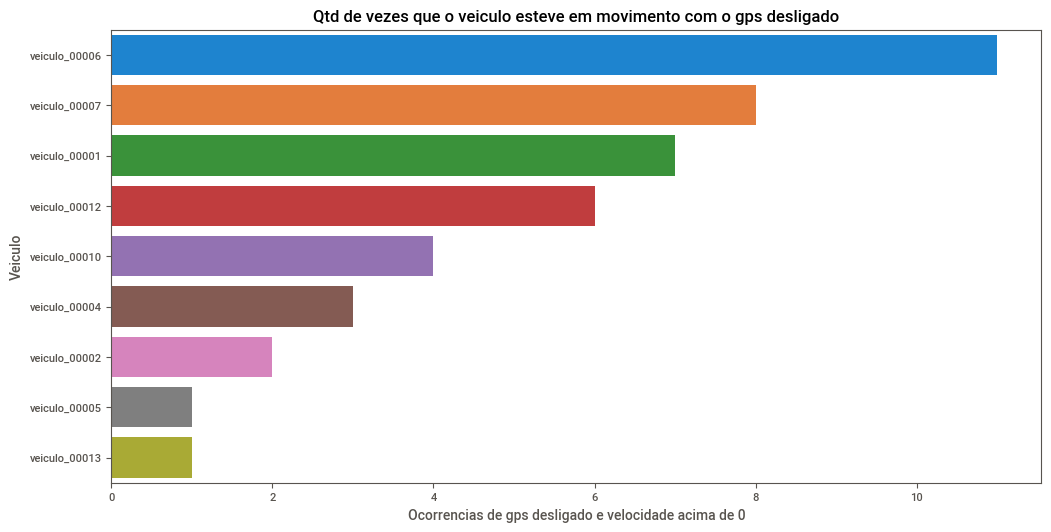

In [51]:
top_resumo_veiculo_gps_off = resumo_veiculo_gps_off.sort_values(by = "ocorr_vel_acima_0_gps_off", ascending= False)

plt.figure(figsize = (12,6))

sn.barplot(
    data = top_resumo_veiculo_gps_off,
    x = "ocorr_vel_acima_0_gps_off",
    y = "veiculo"
)

plt.title("Qtd de vezes que o veiculo esteve em movimento com o gps desligado")
plt.xlabel("Ocorrencias de gps desligado e velocidade acima de 0")
plt.ylabel("Veiculo")

plt.show()

In [52]:
frota_df[ (frota_df["hodometro"] == 0) | (frota_df["hodometro"] == np.nan) ]

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,latitude,longitude,descricao_evento,faixas_velocidade,gravidade_evento,data_posicao,hora_posicao,turno,dia


In [105]:
frota_df[ (frota_df["hodometro"] == 0) | (frota_df["hodometro"] == np.nan) ].__len__

<bound method DataFrame.__len__ of Empty DataFrame
Columns: [sqs_message_id, veiculo, velocidade, altitude, hodometro, gps_status, ignicao, eventCode, bloqueio, latitude, longitude, descricao_evento, faixas_velocidade, gravidade_evento, data_posicao, hora_posicao, turno, dia, data_hora_posicao, dif_hodometro]
Index: []>

In [53]:
# Coluna datetime juntando data_posicao e hora_posicao
frota_df["data_hora_posicao"] = pd.to_datetime(
    frota_df["data_posicao"].astype(str) + " " + frota_df["hora_posicao"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

#frota_df

In [54]:
# O intuito é agregar os veiculos por data/hora decrescentes e calcular a diferença de hodometro
#no tempo x e x-1

frota_df = frota_df.sort_values(["veiculo", "data_hora_posicao"] )
frota_df

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,latitude,longitude,descricao_evento,faixas_velocidade,gravidade_evento,data_posicao,hora_posicao,turno,dia,data_hora_posicao
0,msg_00001,veiculo_00001,65,21.0,23534.723,True,True,44,False,-5.213150,-37.358740,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,05/01/2026,20:29:51,Vespertino,segunda,2026-01-05 20:29:51
160,msg_00161,veiculo_00001,43,19.0,23535.923,True,True,44,False,-5.204426,-37.352417,Report ignição on,41 a 60 km/h - Velocidade urbana,Operacional / status,05/01/2026,20:31:51,Vespertino,segunda,2026-01-05 20:31:51
30,msg_00031,veiculo_00001,18,22.0,23536.349,True,True,44,False,-5.201080,-37.350310,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,05/01/2026,20:33:13,Vespertino,segunda,2026-01-05 20:33:13
91,msg_00092,veiculo_00001,27,22.0,23536.373,True,True,44,False,-5.200936,-37.350450,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:16,Vespertino,segunda,2026-01-05 20:33:16
14,msg_00015,veiculo_00001,37,25.0,23536.601,True,True,44,False,-5.199903,-37.352110,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:51,Vespertino,segunda,2026-01-05 20:33:51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308524,msg_308525,veiculo_00023,42,33.0,21647.674,True,True,111,False,-3.444255,-39.001804,Freada Leve,41 a 60 km/h - Velocidade urbana,Leve / atenção,23/04/2026,15:55:00,Vespertino,quinta,2026-04-23 15:55:00
308525,msg_308526,veiculo_00023,61,33.0,21647.656,True,True,121,False,-3.444255,-39.001804,Freada Brusca,61 a 80 km/h - Velocidade moderada,Crítico / irregularidade,23/04/2026,15:55:00,Vespertino,quinta,2026-04-23 15:55:00
308530,msg_308531,veiculo_00023,64,31.0,21648.246,True,True,44,False,-3.445829,-38.996902,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,23/04/2026,15:55:39,Vespertino,quinta,2026-04-23 15:55:39
308533,msg_308534,veiculo_00023,23,33.0,21648.728,True,True,111,False,-3.447010,-38.992645,Freada Leve,21 a 40 km/h - Velocidade baixa,Leve / atenção,23/04/2026,15:56:09,Vespertino,quinta,2026-04-23 15:56:09


In [55]:
# coluna que calcula a diferenca de hodometro atual e o anterior (por grupo/veiculo)

frota_df["dif_hodometro"] = (
    frota_df
    .groupby("veiculo")["hodometro"]
    .diff()
)

frota_df.head()

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,latitude,longitude,descricao_evento,faixas_velocidade,gravidade_evento,data_posicao,hora_posicao,turno,dia,data_hora_posicao,dif_hodometro
0,msg_00001,veiculo_00001,65,21.0,23534.723,True,True,44,False,-5.213150,-37.358740,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,05/01/2026,20:29:51,Vespertino,segunda,2026-01-05 20:29:51,NaN
160,msg_00161,veiculo_00001,43,19.0,23535.923,True,True,44,False,-5.204426,-37.352417,Report ignição on,41 a 60 km/h - Velocidade urbana,Operacional / status,05/01/2026,20:31:51,Vespertino,segunda,2026-01-05 20:31:51,1.200
30,msg_00031,veiculo_00001,18,22.0,23536.349,True,True,44,False,-5.201080,-37.350310,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,05/01/2026,20:33:13,Vespertino,segunda,2026-01-05 20:33:13,0.426
91,msg_00092,veiculo_00001,27,22.0,23536.373,True,True,44,False,-5.200936,-37.350450,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:16,Vespertino,segunda,2026-01-05 20:33:16,0.024
14,msg_00015,veiculo_00001,37,25.0,23536.601,True,True,44,False,-5.199903,-37.352110,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:51,Vespertino,segunda,2026-01-05 20:33:51,0.228


In [56]:
# Verificando as quedas negativas de hodometro

df_quedas_hodometro = (
    frota_df[frota_df["dif_hodometro"] < 0]
    [["veiculo", "data_hora_posicao", "dif_hodometro"]]
    .copy()
    .sort_values(["veiculo", "data_hora_posicao"])
)

df_quedas_hodometro

,veiculo,data_hora_posicao,dif_hodometro
2269,veiculo_00001,2026-01-06 16:03:46,-0.016
1731,veiculo_00001,2026-01-06 16:06:46,-0.006
4041,veiculo_00001,2026-01-07 10:13:45,-0.014
8231,veiculo_00001,2026-01-08 14:00:23,-0.012
8707,veiculo_00001,2026-01-08 17:48:46,-0.032
...,...,...,...
297410,veiculo_00019,2026-04-18 20:26:34,-0.004
305738,veiculo_00020,2026-04-22 18:46:16,-0.010
305474,veiculo_00022,2026-04-22 18:16:07,-0.006
306698,veiculo_00022,2026-04-22 21:19:23,-0.006


In [57]:
frota_df[["sqs_message_id","data_hora_posicao","veiculo", "hodometro", "dif_hodometro"]].iloc[range(173,176)]

,sqs_message_id,data_hora_posicao,veiculo,hodometro,dif_hodometro
1584,msg_01585,2026-01-06 16:06:46,veiculo_00001,23562.533,1.404
1731,msg_01732,2026-01-06 16:06:46,veiculo_00001,23562.527,-0.006
2273,msg_02274,2026-01-06 16:07:08,veiculo_00001,23562.595,0.068


In [58]:
# Verificando a taxa de erro de leitura do hodometro

erro_hodo = (frota_df["dif_hodometro"] < 0).mean() * 100
print("Percentual de erro de leitura de hodometro: ", round( erro_hodo, 2), "%")

Percentual de erro de leitura de hodometro:  0.24 %


### 2. Qualidade do dispositivo de GPS

- O GPS encontrou-se desligado, em cerca de 1,75% dos registros da base
-  O top3 de maiores ocorrências de GPS desligado por veículo, respectivamente: veiculo_00004, veiculo_00013 e veiculo_00006
-  O top3 de ocorrências de veículos em movimento com GPS desligado, respctivamente: veiculo_00006, veiculo_00007 veiculo_00001
- Não existem ocorrencias de hodometro zerado ou nulo, porém existem cerca de 0,24% de ocorrências em que o hodometro apresentou diminuição ao longo do tempo. O que identifica uma falha de leitura momentânea que em leituras seguintes, são corrigidas.


In [59]:
frota_df

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,latitude,longitude,descricao_evento,faixas_velocidade,gravidade_evento,data_posicao,hora_posicao,turno,dia,data_hora_posicao,dif_hodometro
0,msg_00001,veiculo_00001,65,21.0,23534.723,True,True,44,False,-5.213150,-37.358740,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,05/01/2026,20:29:51,Vespertino,segunda,2026-01-05 20:29:51,NaN
160,msg_00161,veiculo_00001,43,19.0,23535.923,True,True,44,False,-5.204426,-37.352417,Report ignição on,41 a 60 km/h - Velocidade urbana,Operacional / status,05/01/2026,20:31:51,Vespertino,segunda,2026-01-05 20:31:51,1.200
30,msg_00031,veiculo_00001,18,22.0,23536.349,True,True,44,False,-5.201080,-37.350310,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,05/01/2026,20:33:13,Vespertino,segunda,2026-01-05 20:33:13,0.426
91,msg_00092,veiculo_00001,27,22.0,23536.373,True,True,44,False,-5.200936,-37.350450,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:16,Vespertino,segunda,2026-01-05 20:33:16,0.024
14,msg_00015,veiculo_00001,37,25.0,23536.601,True,True,44,False,-5.199903,-37.352110,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:51,Vespertino,segunda,2026-01-05 20:33:51,0.228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308524,msg_308525,veiculo_00023,42,33.0,21647.674,True,True,111,False,-3.444255,-39.001804,Freada Leve,41 a 60 km/h - Velocidade urbana,Leve / atenção,23/04/2026,15:55:00,Vespertino,quinta,2026-04-23 15:55:00,0.422
308525,msg_308526,veiculo_00023,61,33.0,21647.656,True,True,121,False,-3.444255,-39.001804,Freada Brusca,61 a 80 km/h - Velocidade moderada,Crítico / irregularidade,23/04/2026,15:55:00,Vespertino,quinta,2026-04-23 15:55:00,-0.018
308530,msg_308531,veiculo_00023,64,31.0,21648.246,True,True,44,False,-3.445829,-38.996902,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,23/04/2026,15:55:39,Vespertino,quinta,2026-04-23 15:55:39,0.590
308533,msg_308534,veiculo_00023,23,33.0,21648.728,True,True,111,False,-3.447010,-38.992645,Freada Leve,21 a 40 km/h - Velocidade baixa,Leve / atenção,23/04/2026,15:56:09,Vespertino,quinta,2026-04-23 15:56:09,0.482


In [60]:
ig_on_vel_zero = (
    frota_df[ (frota_df["ignicao"] == True) & (frota_df["velocidade"] == 0) ]
    .groupby("veiculo")
    .size()
    .reset_index(name = "ig_on_vel_0")
    .sort_values("ig_on_vel_0", ascending = True)
)

ig_on_vel_zero

,veiculo,ig_on_vel_0
2,veiculo_00003,3
17,veiculo_00018,6
13,veiculo_00014,6
22,veiculo_00023,22
20,veiculo_00021,23
19,veiculo_00020,39
21,veiculo_00022,113
8,veiculo_00009,121
10,veiculo_00011,384
15,veiculo_00016,514


In [61]:
ig_off_vel_acima_zero = (
    frota_df[ (frota_df["velocidade"] > 0) & (frota_df["ignicao"] == False) ]
    .groupby("veiculo")
    .size()
    .reset_index(name = "ig_off_vel_acima_0")
    .sort_values("ig_off_vel_acima_0", ascending = True)
)

ig_off_vel_acima_zero

,veiculo,ig_off_vel_acima_0
13,veiculo_00022,1
8,veiculo_00012,2
11,veiculo_00016,2
2,veiculo_00004,3
7,veiculo_00010,3
9,veiculo_00014,3
5,veiculo_00007,4
10,veiculo_00015,6
3,veiculo_00005,7
6,veiculo_00008,7


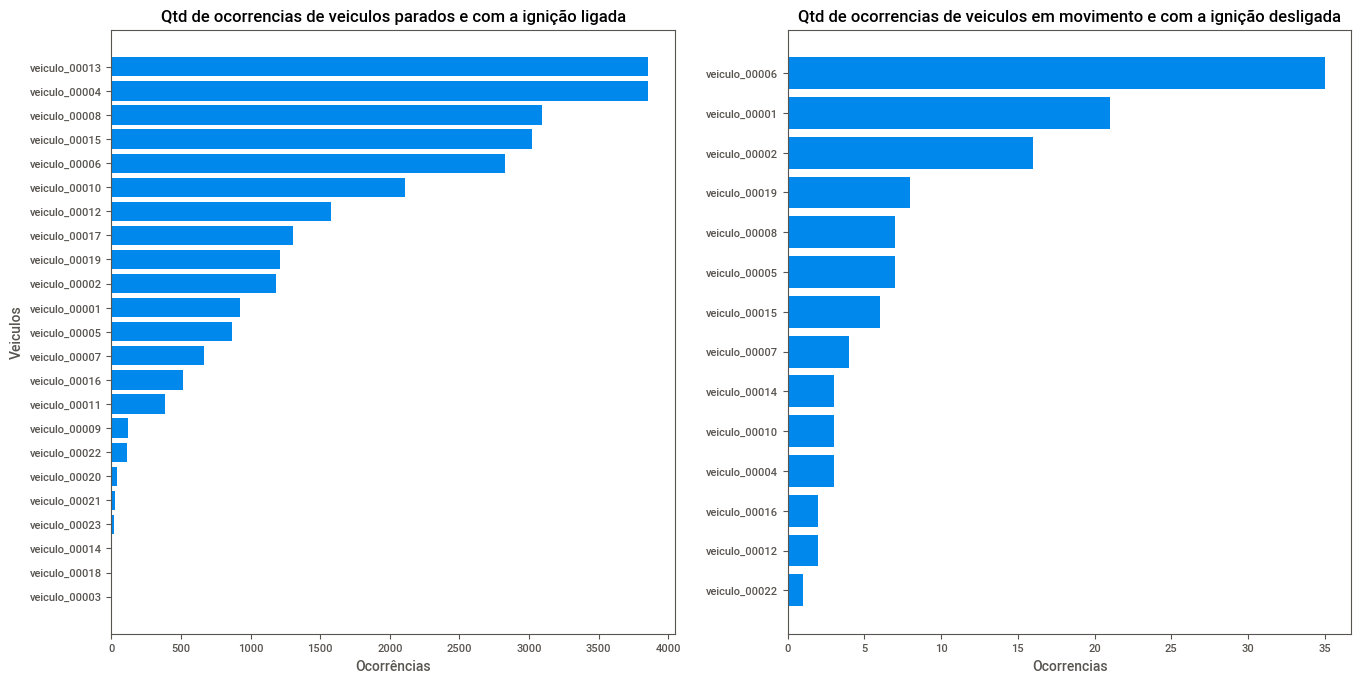

In [62]:

plt.figure(figsize=(16,8))

plt.subplot(1,2,1)
plt.barh(ig_on_vel_zero["veiculo"], ig_on_vel_zero["ig_on_vel_0"])
plt.xlabel("Ocorrências")
plt.ylabel("Veiculos")
plt.title("Qtd de ocorrencias de veiculos parados e com a ignição ligada")

plt.subplot(1,2,2)
plt.barh(ig_off_vel_acima_zero["veiculo"], ig_off_vel_acima_zero["ig_off_vel_acima_0"])
plt.xlabel("Ocorrencias")
plt.title("Qtd de ocorrencias de veiculos em movimento e com a ignição desligada")

plt.show()

### 3. Uso e estado operacional da ignição

- O top3 veículos que permanecem com a ignição acionada, mesmo estando parados são, respectivamente: veiculo_00013, velocidade_00004 e velocidade_00008
- O top3 veículso que estão em movimento mesmo com ignicao desligada são, respectivamente: veiculo_00006, veiculo_00001 e veiculo_00002.

- É possível notar que proporcionalmente o problema maior se concentra na quantidade de veiculos que permanecem parados com a ignicao ligada, o que pode causar desgaste prematuro da bateria, superaquecimento do motor e aumento no consumo do combustível


In [63]:
frota_df.head()

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,latitude,longitude,descricao_evento,faixas_velocidade,gravidade_evento,data_posicao,hora_posicao,turno,dia,data_hora_posicao,dif_hodometro
0,msg_00001,veiculo_00001,65,21.0,23534.723,True,True,44,False,-5.213150,-37.358740,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,05/01/2026,20:29:51,Vespertino,segunda,2026-01-05 20:29:51,NaN
160,msg_00161,veiculo_00001,43,19.0,23535.923,True,True,44,False,-5.204426,-37.352417,Report ignição on,41 a 60 km/h - Velocidade urbana,Operacional / status,05/01/2026,20:31:51,Vespertino,segunda,2026-01-05 20:31:51,1.200
30,msg_00031,veiculo_00001,18,22.0,23536.349,True,True,44,False,-5.201080,-37.350310,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,05/01/2026,20:33:13,Vespertino,segunda,2026-01-05 20:33:13,0.426
91,msg_00092,veiculo_00001,27,22.0,23536.373,True,True,44,False,-5.200936,-37.350450,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:16,Vespertino,segunda,2026-01-05 20:33:16,0.024
14,msg_00015,veiculo_00001,37,25.0,23536.601,True,True,44,False,-5.199903,-37.352110,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:51,Vespertino,segunda,2026-01-05 20:33:51,0.228


In [64]:
resumo_faixas = (
    frota_df#["faixas_velocidade"]
    .groupby("faixas_velocidade")
    .size()
    .reset_index(name="ocorrencias")
    .sort_values(by = "ocorrencias", ascending = True)
)

resumo_faixas


,faixas_velocidade,ocorrencias
7,Acima de 120 km/h - Velocidade crítica,1027
6,101 a 120 km/h - Velocidade muito alta,1111
5,81 a 100 km/h - Velocidade alta,11981
4,61 a 80 km/h - Velocidade moderada,22696
3,41 a 60 km/h - Velocidade urbana,31956
2,21 a 40 km/h - Velocidade baixa,61144
1,1 a 20 km/h - Velocidade muito baixa,86944
0,0 km/h - Veículo parado,91698


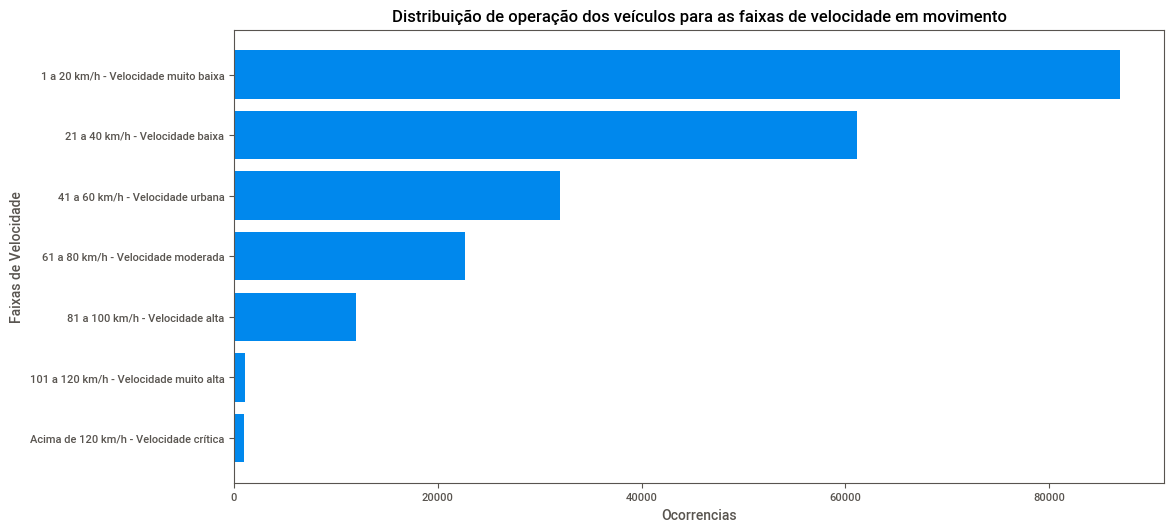

In [65]:
resumo_faixas_movimento = resumo_faixas[ ~(resumo_faixas["faixas_velocidade"] == "0 km/h - Veículo parado") ]

plt.figure(figsize= (12,6))
plt.barh(resumo_faixas_movimento["faixas_velocidade"], resumo_faixas_movimento["ocorrencias"])
plt.title("Distribuição de operação dos veículos para as faixas de velocidade em movimento")
plt.xlabel("Ocorrencias")
plt.ylabel("Faixas de Velocidade")

plt.show()

In [66]:
resumo_faixas_movimento["percentual"] = ( resumo_faixas_movimento["ocorrencias"]/ resumo_faixas_movimento["ocorrencias"].sum()) * 100

resumo_faixas_movimento_ordem = resumo_faixas_movimento.iloc[::-1]
resumo_faixas_movimento_ordem["percentual_acumulado"] = resumo_faixas_movimento_ordem["percentual"].cumsum()

resumo_faixas_movimento_ordem

,faixas_velocidade,ocorrencias,percentual,percentual_acumulado
1,1 a 20 km/h - Velocidade muito baixa,86944,40.092410,40.092410
2,21 a 40 km/h - Velocidade baixa,61144,28.195279,68.287689
3,41 a 60 km/h - Velocidade urbana,31956,14.735842,83.023531
4,61 a 80 km/h - Velocidade moderada,22696,10.465787,93.489318
5,81 a 100 km/h - Velocidade alta,11981,5.524788,99.014106
6,101 a 120 km/h - Velocidade muito alta,1111,0.512314,99.526420
7,Acima de 120 km/h - Velocidade crítica,1027,0.473580,100.000000


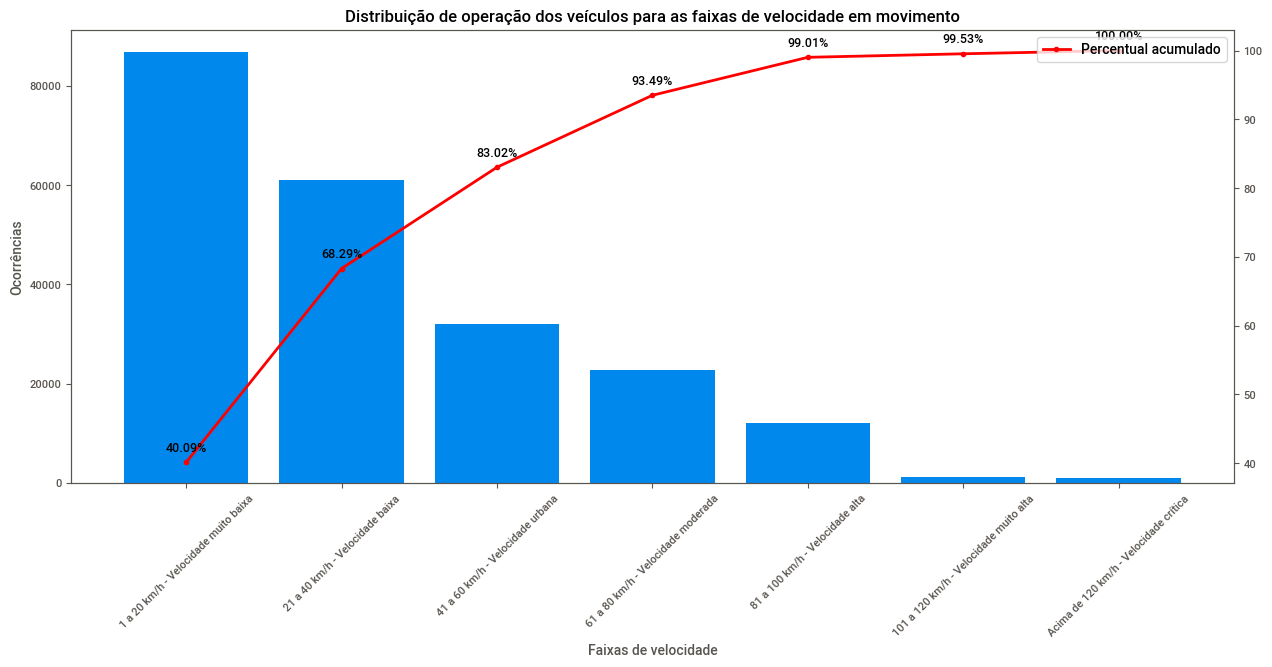

In [67]:
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.bar(
    resumo_faixas_movimento_ordem["faixas_velocidade"].astype(str).to_list(),
    resumo_faixas_movimento_ordem["ocorrencias"].to_numpy()
)

ax1.set_title("Distribuição de operação dos veículos para as faixas de velocidade em movimento")
ax1.set_ylabel("Ocorrências")
ax1.set_xlabel("Faixas de velocidade")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    resumo_faixas_movimento_ordem["faixas_velocidade"].astype(str).to_list(),
    resumo_faixas_movimento_ordem["percentual_acumulado"].to_numpy(),
    
    color="red",
    marker="o",
    linewidth=2,
    label="Percentual acumulado"
)

for x, y in zip(resumo_faixas_movimento_ordem["faixas_velocidade"].astype(str).to_list(), 
                resumo_faixas_movimento_ordem["percentual_acumulado"].to_numpy() ):
    ax2.annotate(
        f"{y:.2f}%",
        xy=(x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )


ax2.set_xlabel("Percentual acumulado (%)")

ax2.legend(loc="upper right")

plt.show()

In [68]:
# Vamos considerar como velocidade elevada, apenas as maiores que 100km
vel_elevada = (
                frota_df[ frota_df["velocidade"] >= 101 ]
                .groupby("veiculo") 
                .size()
                .reset_index(name = "ocorr")
                .sort_values("ocorr")
)

vel_elevada

,veiculo,ocorr
7,veiculo_00009,2
16,veiculo_00020,10
10,veiculo_00012,12
14,veiculo_00017,14
6,veiculo_00008,15
15,veiculo_00019,15
1,veiculo_00002,20
12,veiculo_00015,30
2,veiculo_00004,41
9,veiculo_00011,51


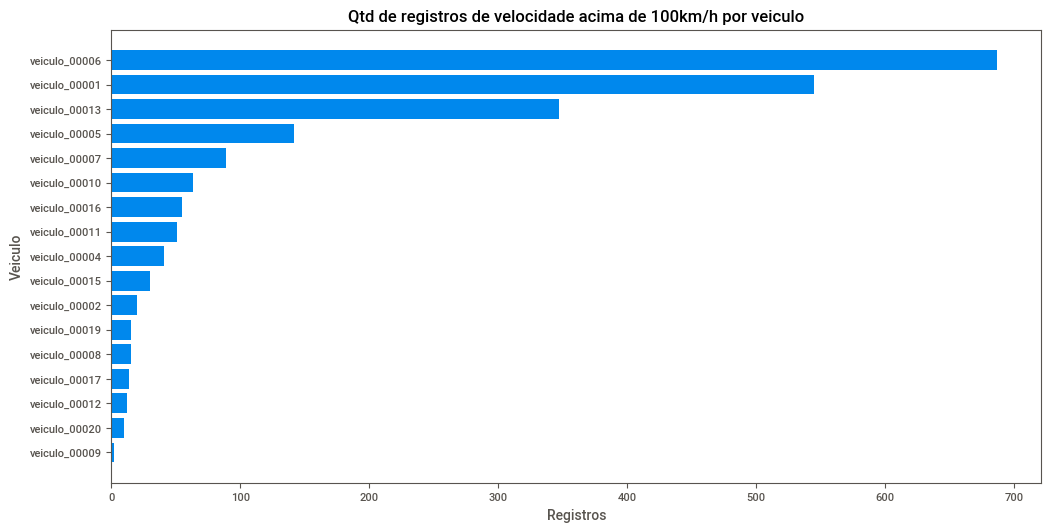

In [69]:
plt.figure(figsize=(12,6))

plt.barh(vel_elevada["veiculo"], vel_elevada["ocorr"])

plt.title("Qtd de registros de velocidade acima de 100km/h por veiculo")
plt.xlabel("Registros")
plt.ylabel("Veiculo")

plt.show()

In [70]:
# Análise considerando eventos cuja velocidade registrada está acima de 100km/h

resumo_vel_evento = (
                    frota_df[ frota_df["velocidade"] >= 101 ]
                    .groupby("descricao_evento")
                    .size()
                    .reset_index(name="registro")
                    .sort_values("registro", ascending = False)

)

resumo_vel_evento

,descricao_evento,registro
3,Report ignição on,1329
5,Velocidade acima do limite,410
4,Velocidade abaixo do limite,363
2,Outros eventos,28
1,Freada Leve,5
0,Curva Leve direita,3


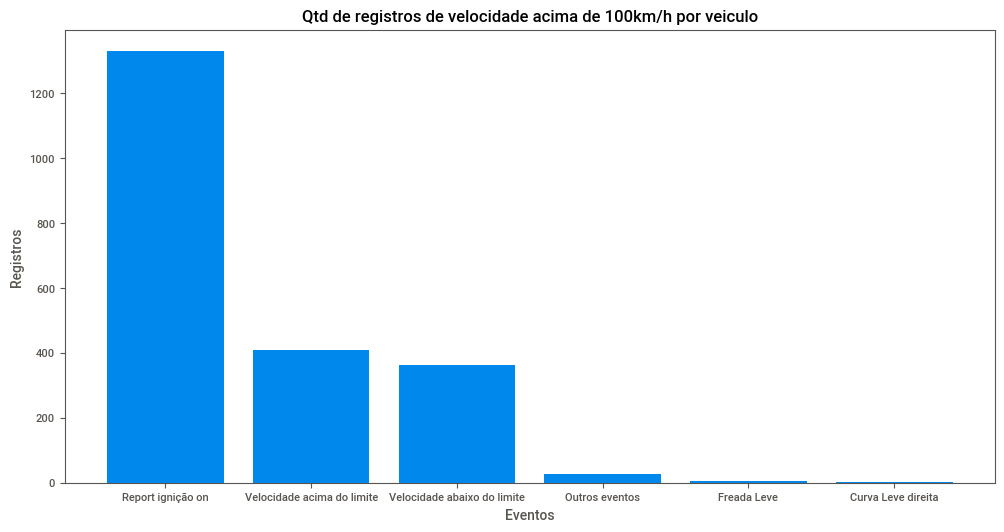

In [106]:
plt.figure(figsize=(12,6))

plt.bar(resumo_vel_evento["descricao_evento"], resumo_vel_evento["registro"])

plt.title("Qtd de registros de velocidade acima de 100km/h por veiculo")
plt.xlabel("Eventos")
plt.ylabel("Registros")

plt.show()

In [72]:
turno_vel_acima = (
                frota_df.loc[ frota_df["velocidade"] >= 101, "turno" ].to_frame()
                .groupby("turno")
                .size()
                .reset_index(name = "ocorren")
                .sort_values("ocorren", ascending = False)
)

turno_vel_acima

,turno,ocorren
2,Vespertino,1322
0,Matutino,804
1,Noturno,12


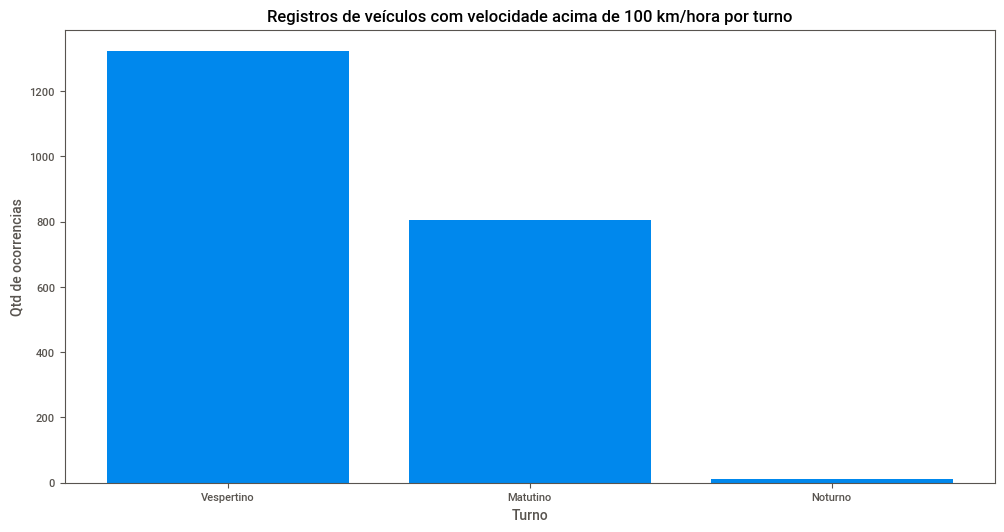

In [73]:
plt.figure(figsize=(12,6))

plt.bar(turno_vel_acima["turno"], turno_vel_acima["ocorren"])

plt.title("Registros de veículos com velocidade acima de 100 km/hora por turno")
plt.xlabel("Turno")
plt.ylabel("Qtd de ocorrencias")

plt.show()

### 4. Velocidade e comportamento de condução

- Cerca de 83% dos registros de velocidade se encontram até 60km/h
- O top3 veiculos que circulam com velocidades acima de 100km/h, respectivamente: veiculo_00006, veiculo_00001 e veiculo_00013
- A velocidade alta registrada nem sempre corresponde ao evento acionado pelo sensor de telemetria. É possível notar que existem muitos eventos de 'acionamento de ignição' durante as altas velocidades. O que pode ter sido provocado por atrasos na leitura do sensor de telemetria.
- O turno que mais ocorre registros de velocidade acima de 100km/h é o Vespertino (14 às 22h)

In [74]:
frota_df

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,latitude,longitude,descricao_evento,faixas_velocidade,gravidade_evento,data_posicao,hora_posicao,turno,dia,data_hora_posicao,dif_hodometro
0,msg_00001,veiculo_00001,65,21.0,23534.723,True,True,44,False,-5.213150,-37.358740,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,05/01/2026,20:29:51,Vespertino,segunda,2026-01-05 20:29:51,NaN
160,msg_00161,veiculo_00001,43,19.0,23535.923,True,True,44,False,-5.204426,-37.352417,Report ignição on,41 a 60 km/h - Velocidade urbana,Operacional / status,05/01/2026,20:31:51,Vespertino,segunda,2026-01-05 20:31:51,1.200
30,msg_00031,veiculo_00001,18,22.0,23536.349,True,True,44,False,-5.201080,-37.350310,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,05/01/2026,20:33:13,Vespertino,segunda,2026-01-05 20:33:13,0.426
91,msg_00092,veiculo_00001,27,22.0,23536.373,True,True,44,False,-5.200936,-37.350450,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:16,Vespertino,segunda,2026-01-05 20:33:16,0.024
14,msg_00015,veiculo_00001,37,25.0,23536.601,True,True,44,False,-5.199903,-37.352110,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:51,Vespertino,segunda,2026-01-05 20:33:51,0.228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308524,msg_308525,veiculo_00023,42,33.0,21647.674,True,True,111,False,-3.444255,-39.001804,Freada Leve,41 a 60 km/h - Velocidade urbana,Leve / atenção,23/04/2026,15:55:00,Vespertino,quinta,2026-04-23 15:55:00,0.422
308525,msg_308526,veiculo_00023,61,33.0,21647.656,True,True,121,False,-3.444255,-39.001804,Freada Brusca,61 a 80 km/h - Velocidade moderada,Crítico / irregularidade,23/04/2026,15:55:00,Vespertino,quinta,2026-04-23 15:55:00,-0.018
308530,msg_308531,veiculo_00023,64,31.0,21648.246,True,True,44,False,-3.445829,-38.996902,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,23/04/2026,15:55:39,Vespertino,quinta,2026-04-23 15:55:39,0.590
308533,msg_308534,veiculo_00023,23,33.0,21648.728,True,True,111,False,-3.447010,-38.992645,Freada Leve,21 a 40 km/h - Velocidade baixa,Leve / atenção,23/04/2026,15:56:09,Vespertino,quinta,2026-04-23 15:56:09,0.482


In [75]:
resumo_gravidade_evento = (
    frota_df[["gravidade_evento"]]
    .groupby("gravidade_evento")
    .size()
    .reset_index(name = "reg")
    .sort_values("reg", ascending = True)

)

resumo_gravidade_evento 

,gravidade_evento,reg
0,Crítico / irregularidade,1955
1,Leve / atenção,9831
3,Outros eventos,29485
2,Operacional / status,267286


In [76]:
resumo_gravidade_evento_percentual = (
    resumo_gravidade_evento 
    .groupby("gravidade_evento")
    .agg(total_reg=("reg", "sum"))
    .reset_index()
    .sort_values("total_reg", ascending = False)
)

resumo_gravidade_evento_percentual["percentual_reg"] = ( resumo_gravidade_evento_percentual["total_reg"] / 
                                                        resumo_gravidade_evento_percentual["total_reg"].sum()) * 100

resumo_gravidade_evento_percentual

,gravidade_evento,total_reg,percentual_reg
2,Operacional / status,267286,86.624513
3,Outros eventos,29485,9.555771
1,Leve / atenção,9831,3.186121
0,Crítico / irregularidade,1955,0.633594


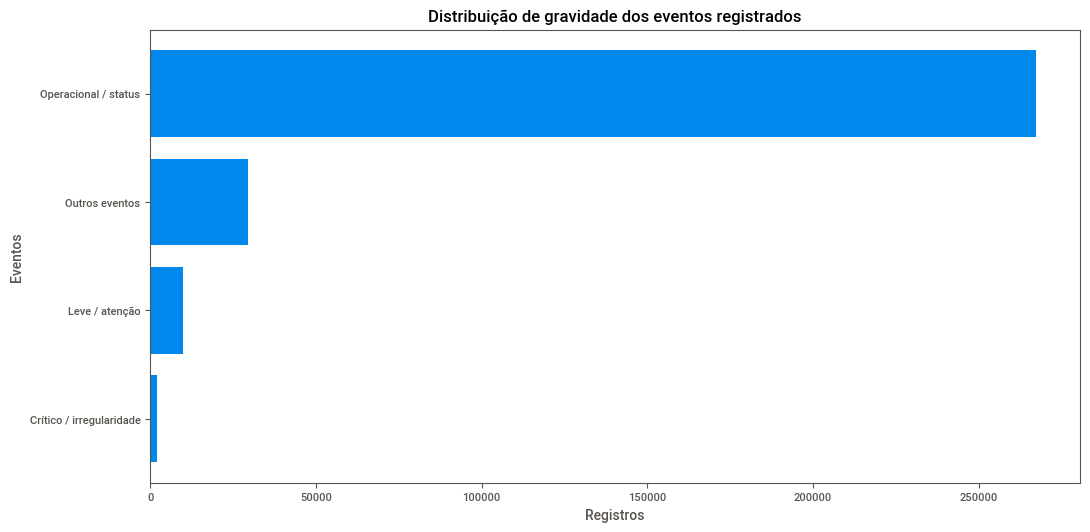

In [77]:
plt.figure(figsize=(12,6))

plt.barh(resumo_gravidade_evento["gravidade_evento"], resumo_gravidade_evento ["reg"])

plt.title("Distribuição de gravidade dos eventos registrados")
plt.xlabel("Registros")
plt.ylabel("Eventos")

plt.show()

In [78]:
resumo_evento_critico = (
    frota_df[frota_df["gravidade_evento"] == "Crítico / irregularidade"]
    .groupby("descricao_evento")
    .size()
    .reset_index(name = "reg")
    .sort_values("reg", ascending = True)

)

resumo_evento_critico

,descricao_evento,reg
0,Aceleração Brusca,301
1,Curva Brusca direita,345
4,Velocidade acima do limite,413
2,Curva Brusca esquerda,448
3,Freada Brusca,448


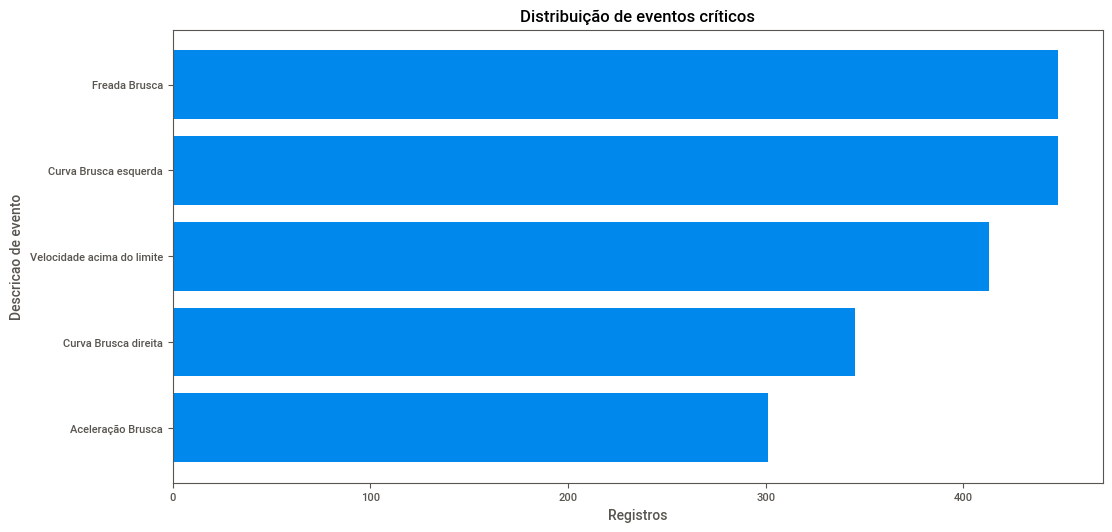

In [79]:
plt.figure(figsize=(12,6))

plt.barh(resumo_evento_critico["descricao_evento"], resumo_evento_critico["reg"])

plt.title("Distribuição de eventos críticos")
plt.xlabel("Registros")
plt.ylabel("Descricao de evento")

plt.show()

In [80]:
resumo_evento_critico_veiculo = (
    frota_df[frota_df["gravidade_evento"] == "Crítico / irregularidade"]
    .groupby("veiculo")
    .size()
    .reset_index(name = "reg")
    .sort_values("reg", ascending = True)

)

resumo_evento_critico_veiculo

,veiculo,reg
7,veiculo_00009,2
16,veiculo_00023,3
15,veiculo_00019,11
9,veiculo_00011,14
2,veiculo_00004,19
10,veiculo_00012,46
5,veiculo_00007,101
6,veiculo_00008,104
3,veiculo_00005,109
14,veiculo_00017,115


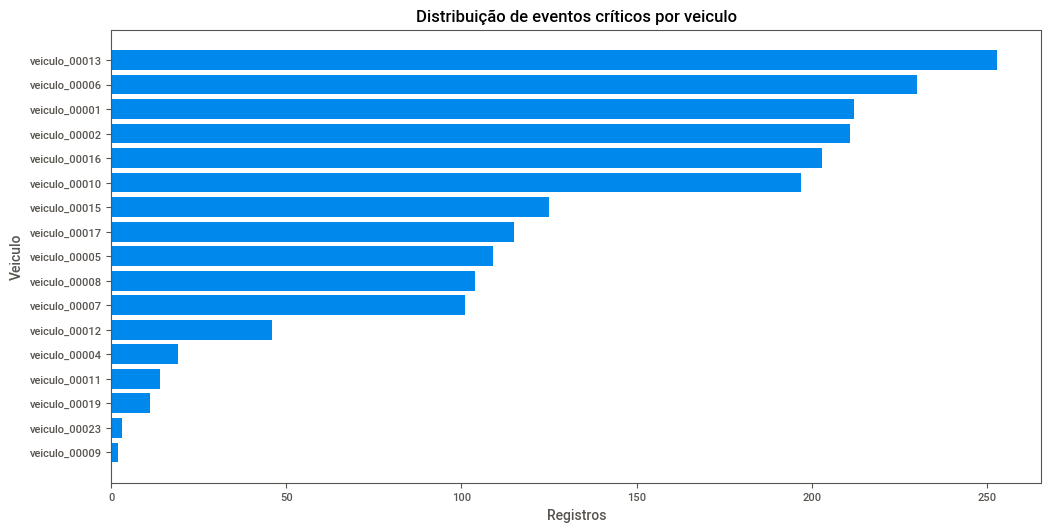

In [81]:
plt.figure(figsize=(12,6))

plt.barh(resumo_evento_critico_veiculo["veiculo"], resumo_evento_critico_veiculo["reg"])

plt.title("Distribuição de eventos críticos por veiculo")
plt.xlabel("Registros")
plt.ylabel("Veiculo")

plt.show()

In [82]:
resumo_evento_critico_turno = (
    frota_df[frota_df["gravidade_evento"] == "Crítico / irregularidade"]
    .groupby("turno")
    .size()
    .reset_index(name = "reg")
    .sort_values("reg", ascending = False)

)

resumo_evento_critico_turno

,turno,reg
2,Vespertino,993
0,Matutino,936
1,Noturno,26


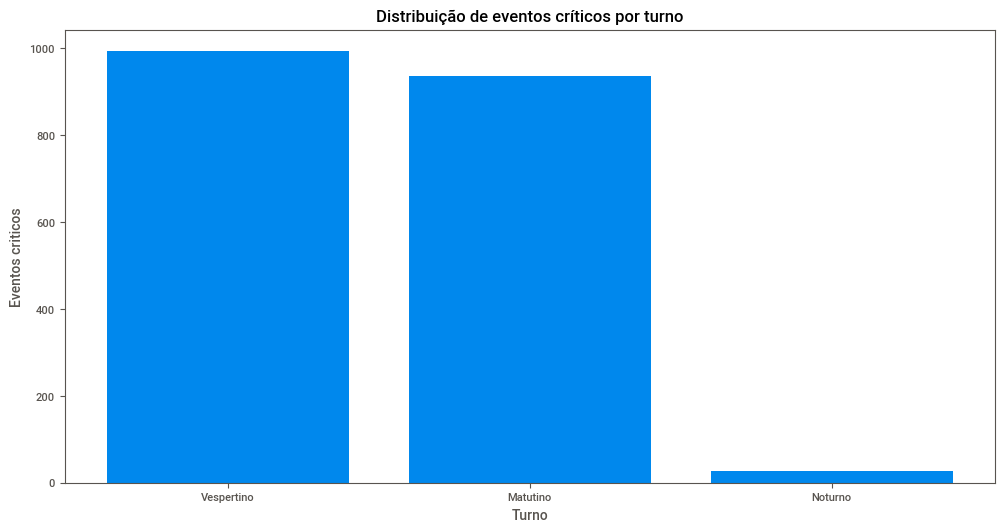

In [83]:
plt.figure(figsize=(12,6))

plt.bar(resumo_evento_critico_turno["turno"], resumo_evento_critico_turno["reg"])

plt.title("Distribuição de eventos críticos por turno")
plt.xlabel("Turno")
plt.ylabel("Eventos criticos")

plt.show()

In [84]:
resumo_evento_leve_veiculo = (
    frota_df[frota_df["gravidade_evento"] == "Leve / atenção"]
    .groupby("veiculo")
    .size()
    .reset_index(name = "reg")
    .sort_values("reg", ascending = True)

)

resumo_evento_leve_veiculo

,veiculo,reg
15,veiculo_00018,1
18,veiculo_00021,8
19,veiculo_00022,13
7,veiculo_00009,20
17,veiculo_00020,21
20,veiculo_00023,26
9,veiculo_00011,161
16,veiculo_00019,194
2,veiculo_00004,269
10,veiculo_00012,337


In [85]:
resumo_evento_leve_veiculo.describe()

,reg
count,21.000000
mean,468.142857
std,432.810731
min,1.000000
25%,26.000000
50%,466.000000
75%,742.000000
max,1463.000000


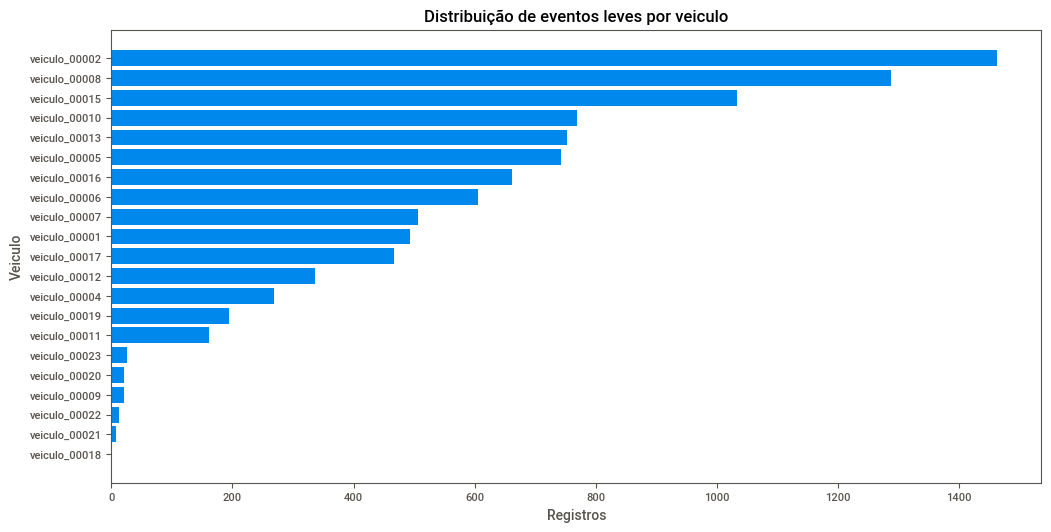

In [86]:
plt.figure(figsize=(12,6))

plt.barh(resumo_evento_leve_veiculo["veiculo"], resumo_evento_leve_veiculo["reg"])

plt.title("Distribuição de eventos leves por veiculo")
plt.xlabel("Registros")
plt.ylabel("Veiculo")

plt.show()

### 5. Eventos críticos e irregularidades
- Eventos criticos e leves somam menos de 4% dos registros da base. A maioria se concentra em status operacionais
- O top3 de eventos criticos mais frequentes são, respectivamente: freada brusca, curva brusca a esquerda e velocidade acima do limite.
- O top3 veiculos que mais concentram registros de eventos críticos, respectivamnte: veiculo_00013, veiculo_00006 e veiculo_00001
- Os eventos críticos se concentram, essencialmente, nos turnos matutino e vespertino
- Considerando veiculos acima do terceiro quartil (Q3/75%), os veículos que possuem excesso de eventos leves, são: veiculo_00002, veiculo_00008, veiculo_00015, veiculo_00010 e veiculo_00013

In [87]:
frota_df

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,latitude,longitude,descricao_evento,faixas_velocidade,gravidade_evento,data_posicao,hora_posicao,turno,dia,data_hora_posicao,dif_hodometro
0,msg_00001,veiculo_00001,65,21.0,23534.723,True,True,44,False,-5.213150,-37.358740,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,05/01/2026,20:29:51,Vespertino,segunda,2026-01-05 20:29:51,NaN
160,msg_00161,veiculo_00001,43,19.0,23535.923,True,True,44,False,-5.204426,-37.352417,Report ignição on,41 a 60 km/h - Velocidade urbana,Operacional / status,05/01/2026,20:31:51,Vespertino,segunda,2026-01-05 20:31:51,1.200
30,msg_00031,veiculo_00001,18,22.0,23536.349,True,True,44,False,-5.201080,-37.350310,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,05/01/2026,20:33:13,Vespertino,segunda,2026-01-05 20:33:13,0.426
91,msg_00092,veiculo_00001,27,22.0,23536.373,True,True,44,False,-5.200936,-37.350450,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:16,Vespertino,segunda,2026-01-05 20:33:16,0.024
14,msg_00015,veiculo_00001,37,25.0,23536.601,True,True,44,False,-5.199903,-37.352110,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:51,Vespertino,segunda,2026-01-05 20:33:51,0.228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308524,msg_308525,veiculo_00023,42,33.0,21647.674,True,True,111,False,-3.444255,-39.001804,Freada Leve,41 a 60 km/h - Velocidade urbana,Leve / atenção,23/04/2026,15:55:00,Vespertino,quinta,2026-04-23 15:55:00,0.422
308525,msg_308526,veiculo_00023,61,33.0,21647.656,True,True,121,False,-3.444255,-39.001804,Freada Brusca,61 a 80 km/h - Velocidade moderada,Crítico / irregularidade,23/04/2026,15:55:00,Vespertino,quinta,2026-04-23 15:55:00,-0.018
308530,msg_308531,veiculo_00023,64,31.0,21648.246,True,True,44,False,-3.445829,-38.996902,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,23/04/2026,15:55:39,Vespertino,quinta,2026-04-23 15:55:39,0.590
308533,msg_308534,veiculo_00023,23,33.0,21648.728,True,True,111,False,-3.447010,-38.992645,Freada Leve,21 a 40 km/h - Velocidade baixa,Leve / atenção,23/04/2026,15:56:09,Vespertino,quinta,2026-04-23 15:56:09,0.482


In [88]:
# O estado de 'bloqueio' do veiculo, diz respeito sobre a não autorização do veículo de rodar, ou seja, não pode ser dirigido naquele momento
# Verificando a situação dos veículos nesse estado

frota_df.loc[ frota_df["bloqueio"] == True, "veiculo"].unique()

#Na base, apenas o veiculo_00014 teve registros de bloqueio

array(['veiculo_00014'], dtype=object)

In [89]:
frota_df[ (frota_df["bloqueio"] == True) & (frota_df["velocidade"] > 0) ][["veiculo", "velocidade", "descricao_evento"]]

,veiculo,velocidade,descricao_evento
152359,veiculo_00014,6,Início do trajeto
205595,veiculo_00014,1,Outros eventos


In [90]:
frota_df[ (frota_df["bloqueio"] == True) & (frota_df["ignicao"] == True) ][["veiculo", "velocidade", "ignicao", "data_hora_posicao"]]

,veiculo,velocidade,ignicao,data_hora_posicao
152344,veiculo_00014,0,True,2026-03-02 19:21:57
152345,veiculo_00014,0,True,2026-03-02 19:22:17
152356,veiculo_00014,0,True,2026-03-02 19:23:56
152359,veiculo_00014,6,True,2026-03-02 19:24:28
152366,veiculo_00014,0,True,2026-03-02 19:25:37
152378,veiculo_00014,0,True,2026-03-02 19:29:14
152382,veiculo_00014,0,True,2026-03-02 19:29:48


In [91]:
# velocidades com eventos tageados como 'velocidade acima do limite'
frota_df[ frota_df["eventCode"] == 90 ][ "velocidade"].unique()

array([  0, 129, 130, 136, 134, 132, 137, 126, 128, 131, 138, 143, 135,
       140, 144, 139, 133, 146, 158, 148, 145, 124, 152, 127], dtype=int64)

In [108]:
frota_df[ (frota_df["eventCode"] == 90) & (frota_df["velocidade"] == 0)][["sqs_message_id", "veiculo", "velocidade", "descricao_evento", "data_posicao"]]

,sqs_message_id,veiculo,velocidade,descricao_evento,data_posicao
8406,msg_08407,veiculo_00001,0,Velocidade acima do limite,08/01/2026
11930,msg_11931,veiculo_00001,0,Velocidade acima do limite,09/01/2026
38473,msg_38474,veiculo_00001,0,Velocidade acima do limite,20/01/2026


### 6. Bloqueio e inconsistências operacionais
- Apenas o veiculo_00014 teve histórico de bloqueio
- O veiculo_00014 possue dois momentos em que esteve bloqueado e com velocidade um pouco acima de 0. Pode ser indício de algum erro de leitura
- O veiculo_00014 possui 7 registros de ignição acionada, mesmo estando em bloqueio, em data/horas que vão de 02/03/2026-19:21:57 a 02/03/2026-19:29:48
- Apenas o veículo_00001 possui alguns registros de 'velocidade acima do limite' mas esteve com velocidade igual a 0

In [93]:
frota_df

,sqs_message_id,veiculo,velocidade,altitude,hodometro,gps_status,ignicao,eventCode,bloqueio,latitude,longitude,descricao_evento,faixas_velocidade,gravidade_evento,data_posicao,hora_posicao,turno,dia,data_hora_posicao,dif_hodometro
0,msg_00001,veiculo_00001,65,21.0,23534.723,True,True,44,False,-5.213150,-37.358740,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,05/01/2026,20:29:51,Vespertino,segunda,2026-01-05 20:29:51,NaN
160,msg_00161,veiculo_00001,43,19.0,23535.923,True,True,44,False,-5.204426,-37.352417,Report ignição on,41 a 60 km/h - Velocidade urbana,Operacional / status,05/01/2026,20:31:51,Vespertino,segunda,2026-01-05 20:31:51,1.200
30,msg_00031,veiculo_00001,18,22.0,23536.349,True,True,44,False,-5.201080,-37.350310,Report ignição on,1 a 20 km/h - Velocidade muito baixa,Operacional / status,05/01/2026,20:33:13,Vespertino,segunda,2026-01-05 20:33:13,0.426
91,msg_00092,veiculo_00001,27,22.0,23536.373,True,True,44,False,-5.200936,-37.350450,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:16,Vespertino,segunda,2026-01-05 20:33:16,0.024
14,msg_00015,veiculo_00001,37,25.0,23536.601,True,True,44,False,-5.199903,-37.352110,Report ignição on,21 a 40 km/h - Velocidade baixa,Operacional / status,05/01/2026,20:33:51,Vespertino,segunda,2026-01-05 20:33:51,0.228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308524,msg_308525,veiculo_00023,42,33.0,21647.674,True,True,111,False,-3.444255,-39.001804,Freada Leve,41 a 60 km/h - Velocidade urbana,Leve / atenção,23/04/2026,15:55:00,Vespertino,quinta,2026-04-23 15:55:00,0.422
308525,msg_308526,veiculo_00023,61,33.0,21647.656,True,True,121,False,-3.444255,-39.001804,Freada Brusca,61 a 80 km/h - Velocidade moderada,Crítico / irregularidade,23/04/2026,15:55:00,Vespertino,quinta,2026-04-23 15:55:00,-0.018
308530,msg_308531,veiculo_00023,64,31.0,21648.246,True,True,44,False,-3.445829,-38.996902,Report ignição on,61 a 80 km/h - Velocidade moderada,Operacional / status,23/04/2026,15:55:39,Vespertino,quinta,2026-04-23 15:55:39,0.590
308533,msg_308534,veiculo_00023,23,33.0,21648.728,True,True,111,False,-3.447010,-38.992645,Freada Leve,21 a 40 km/h - Velocidade baixa,Leve / atenção,23/04/2026,15:56:09,Vespertino,quinta,2026-04-23 15:56:09,0.482


In [94]:
df_heatmap = frota_df.copy()

#Criando colunas Binárias a partir do frota_df
# Lembrar de extrair apenas as colunas binarias e de veiculo para construir o heatmap

df_heatmap["evento_critico"] = df_heatmap["gravidade_evento"] == "Crítico / irregularidade"

df_heatmap["gps_desligado"] = df_heatmap["gps_status"] == False

df_heatmap["parado_com_ignicao_ligada"] = ( (df_heatmap["velocidade"] == 0) & (df_heatmap["ignicao"] == True) )

df_heatmap["movimento_com_ignicao_desligada"] = ( (df_heatmap["velocidade"] > 0) & (df_heatmap["ignicao"] == False) )

df_heatmap["bloqueado_com_ignicao_ligada"] = ((df_heatmap["bloqueio"] == True) & (df_heatmap["ignicao"] == True))

df_heatmap["bloqueado_em_movimento"] = ( (df_heatmap["bloqueio"] == True) &(df_heatmap["velocidade"] > 0) )

In [95]:
frota_df_heatmap = df_heatmap[["veiculo", "evento_critico", "gps_desligado", "parado_com_ignicao_ligada", 
                               "movimento_com_ignicao_desligada", "bloqueado_com_ignicao_ligada", "bloqueado_em_movimento"]]

frota_df_heatmap.head()

,veiculo,evento_critico,gps_desligado,parado_com_ignicao_ligada,movimento_com_ignicao_desligada,bloqueado_com_ignicao_ligada,bloqueado_em_movimento
0,veiculo_00001,False,False,False,False,False,False
160,veiculo_00001,False,False,False,False,False,False
30,veiculo_00001,False,False,False,False,False,False
91,veiculo_00001,False,False,False,False,False,False
14,veiculo_00001,False,False,False,False,False,False


In [96]:
matriz_risco_veiculo = (
    df_heatmap
    .groupby("veiculo")
    .agg(
        evento_critico=("evento_critico", "sum"),
        gps_desligado=("gps_desligado", "sum"),
        parado_com_ignicao_ligada=("parado_com_ignicao_ligada", "sum"),
        movimento_com_ignicao_desligada=("movimento_com_ignicao_desligada", "sum"),
        bloqueado_com_ignicao_ligada=("bloqueado_com_ignicao_ligada", "sum"),
        bloqueado_em_movimento=("bloqueado_em_movimento", "sum")
    )
)

matriz_risco_veiculo

,evento_critico,gps_desligado,parado_com_ignicao_ligada,movimento_com_ignicao_desligada,bloqueado_com_ignicao_ligada,bloqueado_em_movimento
veiculo,,,,,,
veiculo_00001,212,304,923,21,0,0
veiculo_00002,211,267,1182,16,0,0
veiculo_00003,0,3,3,0,0,0
veiculo_00004,19,638,3856,3,0,0
veiculo_00005,109,198,867,7,0,0
veiculo_00006,230,493,2830,35,0,0
veiculo_00007,101,324,664,4,0,0
veiculo_00008,104,466,3093,7,0,0
veiculo_00009,2,45,121,0,0,0


In [97]:
# Vou normalizar a matriz pra garantir melhor visualização no heatmap

matriz_normalizada = matriz_risco_veiculo.apply(
    lambda col: col / col.max(),
    axis=0 # Aplica a função por coluna
)

matriz_normalizada

,evento_critico,gps_desligado,parado_com_ignicao_ligada,movimento_com_ignicao_desligada,bloqueado_com_ignicao_ligada,bloqueado_em_movimento
veiculo,,,,,,
veiculo_00001,0.837945,0.476489,0.239367,0.600000,0.0,0.0
veiculo_00002,0.833992,0.418495,0.306535,0.457143,0.0,0.0
veiculo_00003,0.000000,0.004702,0.000778,0.000000,0.0,0.0
veiculo_00004,0.075099,1.000000,1.000000,0.085714,0.0,0.0
veiculo_00005,0.430830,0.310345,0.224844,0.200000,0.0,0.0
veiculo_00006,0.909091,0.772727,0.733921,1.000000,0.0,0.0
veiculo_00007,0.399209,0.507837,0.172199,0.114286,0.0,0.0
veiculo_00008,0.411067,0.730408,0.802127,0.200000,0.0,0.0
veiculo_00009,0.007905,0.070533,0.031380,0.000000,0.0,0.0


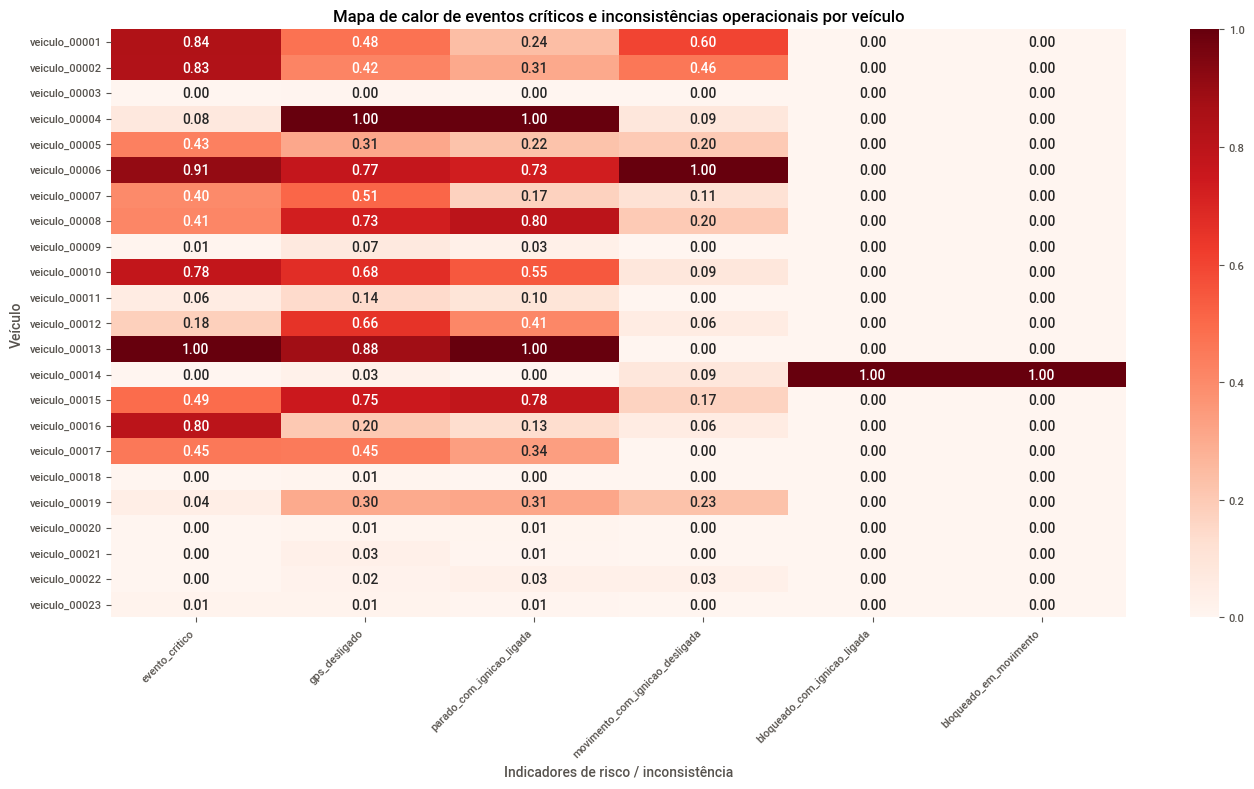

In [98]:
plt.figure(figsize=(14, 8))

sn.heatmap(
    matriz_normalizada,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Mapa de calor de eventos críticos e inconsistências operacionais por veículo")
plt.xlabel("Indicadores de risco / inconsistência")
plt.ylabel("Veículo")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [99]:
matriz_normalizada["total"] = matriz_normalizada.sum(axis= 1)

matriz_normalizada= matriz_normalizada.sort_values(  by="total", ascending=True )



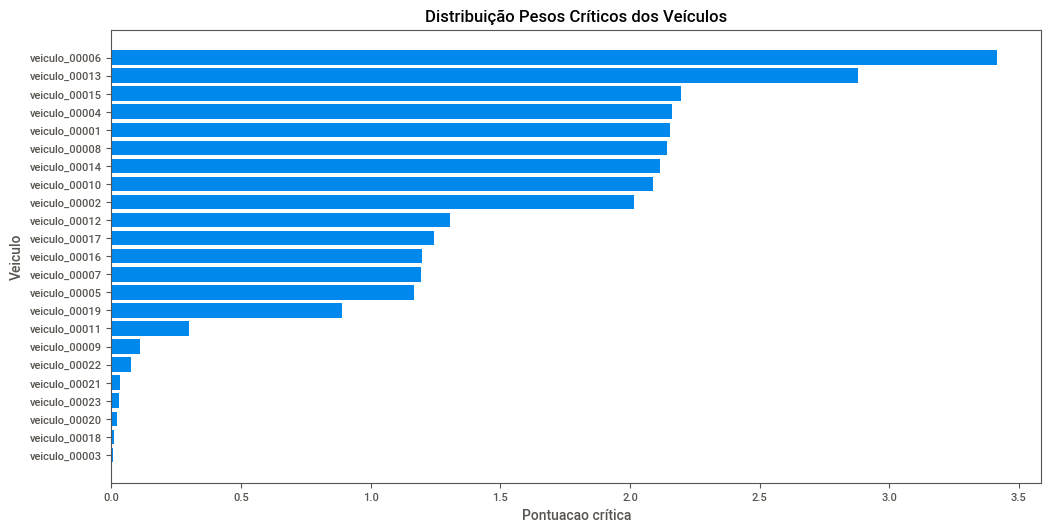

In [100]:
plt.figure(figsize=(12,6))

plt.barh(matriz_normalizada.index, matriz_normalizada["total"])

plt.title("Distribuição Pesos Críticos dos Veículos")
plt.xlabel("Pontuacao crítica")
plt.ylabel("Veiculo")

plt.show()

### 7. Priorização de veiculos

- Dado a distribuição de pesos críticos dos veículos, é preciso investigar, principalmente, os veículos: veiculo_00006 e veiculo_00013.
- Os veículos que apresentam melhor comportamento operacional são, respectivamente: veiculo_00003, veiculo_00018, veiculo_00020, veiculo_00023, veiculo_00021, veiculo_00022, veiculo_00009 e veiculo_00011